# Lab 3: Quantum Fourier Transform

> **Motivating question:** Why does a change of basis help reveal hidden structure, and why is phase the resource that makes that idea powerful in quantum computing?

**Learning goals**
- explain why Fourier-style thinking is useful even before writing down the QFT formula
- describe classical Fourier intuition as a change from a raw signal description to an oscillation-based description
- explain why phase is a computationally meaningful part of a quantum state, not decorative notation
- recognize that two states can have the same amplitude magnitudes and still behave differently because of phase
- build the conceptual bridge needed for later sections on QFT, inverse QFT, and phase estimation

**Notebook roadmap**
1. Why Fourier ideas matter
2. Classical Fourier intuition in simple language
3. Why phase matters in quantum computing
4. What QFT does
5. How QFT acts on basis states
6. QFT circuit anatomy
7. Inverse QFT
8. Hands-on QFT experiments in Qiskit
9. QFT in phase estimation and the Shor connection

This lab combines **theory and hands-on work**. In this opening batch, we build the conceptual motivation only: no QFT definition yet, no QFT circuit yet, and no implementation yet. The goal is to make the later QFT sections feel earned rather than abrupt.

In [49]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.patches import Rectangle
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Operator, Statevector

from utilities.complexity_utils import COLORS, setup_lecture_style

setup_lecture_style()
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlepad'] = 10
np.set_printoptions(precision=3, suppress=True)


## 1. Why Fourier Ideas Matter

**Concept question:** Why would we ever change representation if the underlying object stays the same?

A good representation does not change the information. It changes **how visible the structure is**.

That idea appears everywhere in science and computation:
- a list of pixel values can be reorganized into low-frequency and high-frequency image content,
- a vibration can be described as one messy waveform or as a few clean oscillatory components,
- a matrix can be hard to understand in one basis and simple in another basis where its action is more organized.

Fourier-style transforms are important because they often move us from a description that is **local and mixed together** to one that is **structured by oscillation**. In the new representation, repeating patterns, periodic behavior, and phase relationships stop being hidden inside a long list of numbers.

That is the key reason to care before quantum computing even enters the story. Some problems become easier to analyze after a basis change because the new basis lines up with the behavior of the system.

For later QFT sections, the idea to keep in mind is simple:

> **Representation changes are useful when they turn a complicated-looking description into one where the important pattern is easier to read.**

In classical Fourier analysis, the important pattern is often **which oscillations are present**. In quantum computing, the important pattern will be **how amplitudes and phases are arranged across basis states**.

## 2. Classical Fourier Intuition in Simple Language

**Concept question:** What does it mean to decompose a signal into oscillatory pieces?

Imagine listening to a musical sound. The waveform in time can look complicated, but that does not mean the sound is structureless. Very often it is a combination of a few simpler oscillations layered together.

That is the basic Fourier idea:
- the **time-domain view** asks: what value does the signal have right now?
- the **frequency-domain view** asks: which oscillatory components are present, and how strongly?

The second view is powerful because it can expose a clean pattern inside something that looked messy at first.

You do not need advanced signal processing here. The intuition we want is narrower and more useful for QFT:

> A complicated object can sometimes be understood better by expressing it as a combination of structured oscillatory building blocks.

In the visual below, the left panel shows a signal built from a few sine waves. The right panel reorganizes the same information by frequency. The signal itself has not changed. What changed is **which pattern becomes easy to see**.

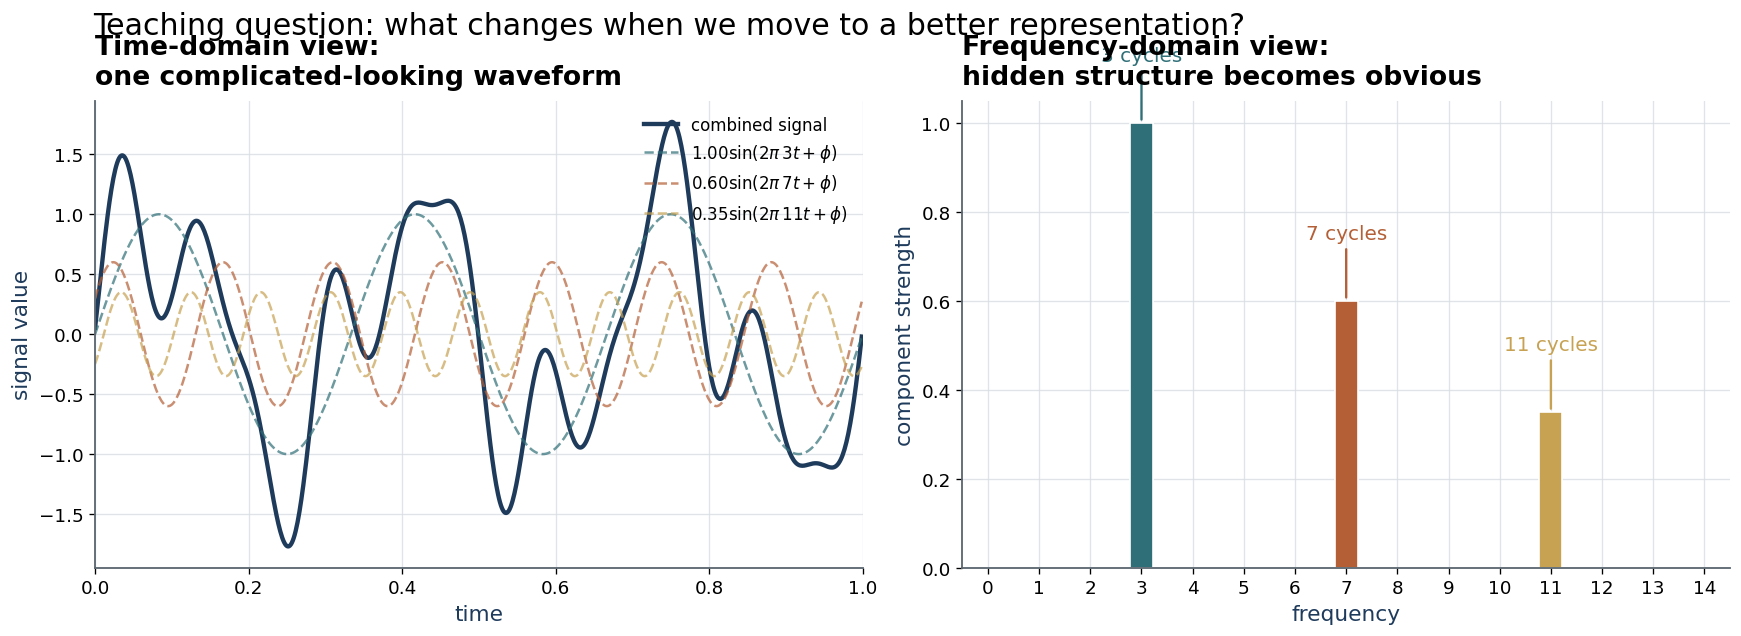

In [50]:
t = np.linspace(0.0, 1.0, 800, endpoint=False)
components = [
    {'frequency': 3, 'amplitude': 1.00, 'phase': 0.00},
    {'frequency': 7, 'amplitude': 0.60, 'phase': np.pi / 6},
    {'frequency': 11, 'amplitude': 0.35, 'phase': -np.pi / 4},
]

signal = np.zeros_like(t)
component_colors = [COLORS['teal'], COLORS['rust'], COLORS['gold']]
for component in components:
    signal += component['amplitude'] * np.sin(2 * np.pi * component['frequency'] * t + component['phase'])

freq_axis = np.fft.rfftfreq(t.size, d=t[1] - t[0])
spectrum = 2 * np.abs(np.fft.rfft(signal)) / t.size

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.0), constrained_layout=True)

axes[0].plot(t, signal, color=COLORS['navy'], label='combined signal')
for color, component in zip(component_colors, components):
    component_wave = component['amplitude'] * np.sin(2 * np.pi * component['frequency'] * t + component['phase'])
    axes[0].plot(
        t,
        component_wave,
        linestyle='--',
        linewidth=1.5,
        alpha=0.7,
        color=color,
        label=fr"{component['amplitude']:.2f}$\sin(2\pi\,{component['frequency']}t + \phi)$",
    )
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('time')
axes[0].set_ylabel('signal value')
axes[0].set_title('Time-domain view:\none complicated-looking waveform', loc='left')
axes[0].legend(fontsize=10, loc='upper right')

mask = (freq_axis >= 0) & (freq_axis <= 14)
bar_colors = []
for frequency in freq_axis[mask]:
    if any(np.isclose(frequency, component['frequency']) for component in components):
        matching_index = next(index for index, component in enumerate(components) if np.isclose(frequency, component['frequency']))
        bar_colors.append(component_colors[matching_index])
    else:
        bar_colors.append(COLORS['light_gray'])

axes[1].bar(freq_axis[mask], spectrum[mask], width=0.45, color=bar_colors, edgecolor='white')
axes[1].set_xlabel('frequency')
axes[1].set_ylabel('component strength')
axes[1].set_title('Frequency-domain view:\nhidden structure becomes obvious', loc='left')
axes[1].set_xticks(range(0, 15))
axes[1].set_xlim(-0.5, 14.5)

for color, component in zip(component_colors, components):
    axes[1].annotate(
        f"{component['frequency']} cycles",
        xy=(component['frequency'], component['amplitude']),
        xytext=(component['frequency'], component['amplitude'] + 0.14),
        ha='center',
        color=color,
        arrowprops={'arrowstyle': '-', 'color': color, 'linewidth': 1.4},
    )

fig.suptitle('Teaching question: what changes when we move to a better representation?', x=0.05, ha='left', y=1.03)
plt.show()


The two panels above contain the **same signal**, but they organize it differently.

- In the time-domain picture, the signal is readable but not very transparent.
- In the frequency-domain picture, the three dominant oscillations become easy to identify immediately.

That is the habit of mind we need for QFT. We should not think of a Fourier transform as mystical frequency-finding. It is better to think of it as a **basis change that reorganizes information around oscillatory structure**.

> **Takeaway:** Fourier-style transforms are useful because they can turn a mixed, local description into one where periodic structure is easier to read. Later, the QFT will do a quantum version of this reorganization, but with amplitudes and phases instead of ordinary signal samples.

## 3. Why Phase Matters in Quantum Computing

**Concept question:** If measurement probabilities come from squared magnitudes, why should we care about phase at all?

A quantum state is built from **complex amplitudes**, not just nonnegative probabilities. That means each basis-state amplitude carries two distinct pieces of information:
- its **magnitude**, which influences immediate measurement probabilities,
- its **phase**, which influences how amplitudes combine later.

This second point is the important one. Phase is what makes **interference** possible.

When amplitudes are combined by later gates or by a measurement in another basis, their phases can make contributions:
- reinforce each other,
- partially cancel,
- or cancel exactly.

So phase is not an optional decoration attached to the state after the real computation is over. Phase is part of what the computation is manipulating.

A very small example already shows this. The states
$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}},
\qquad
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$
have the **same amplitude magnitudes** in the computational basis. If you only look at magnitudes, they appear identical. But they differ by a relative phase of $\pi$ on the $|1\rangle$ component, and that makes them behave differently after a basis change.

> **Common misconception:** phase is not usually read out directly by a single computational-basis measurement. But it still matters, because later interference can convert phase differences into different measurement statistics.

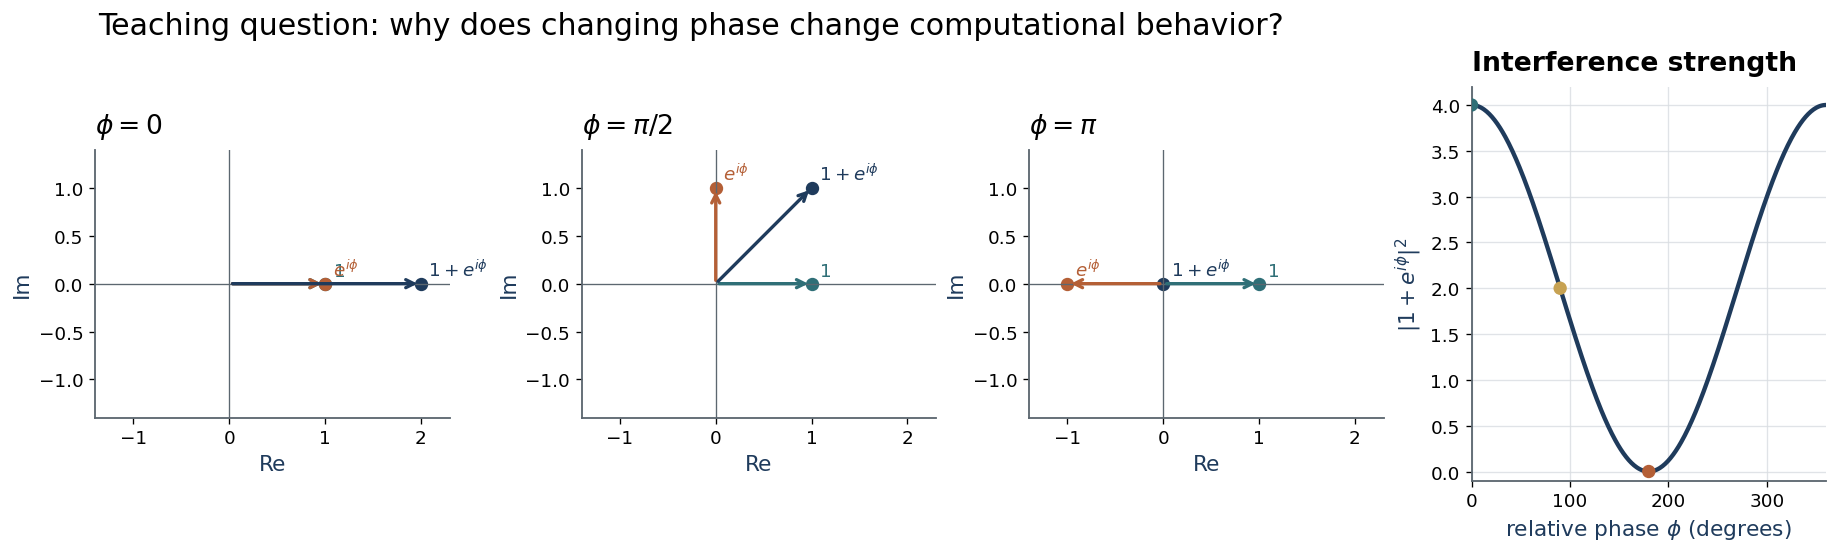

In [51]:
phase_samples = [0.0, np.pi / 2, np.pi]
phase_labels = [r'$\phi = 0$', r'$\phi = \pi / 2$', r'$\phi = \pi$']
phi_grid = np.linspace(0, 2 * np.pi, 400)
interference_strength = np.abs(1 + np.exp(1j * phi_grid)) ** 2

fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.5), constrained_layout=True)

for ax, phi, label in zip(axes[:3], phase_samples, phase_labels):
    z1 = 1 + 0j
    z2 = np.exp(1j * phi)
    total = z1 + z2

    for value, color, text in [
        (z1, COLORS['teal'], r'$1$'),
        (z2, COLORS['rust'], r'$e^{i\phi}$'),
        (total, COLORS['navy'], r'$1 + e^{i\phi}$'),
    ]:
        ax.annotate('', xy=(value.real, value.imag), xytext=(0, 0), arrowprops={'arrowstyle': '->', 'color': color, 'linewidth': 2.0})
        ax.plot(value.real, value.imag, 'o', color=color, markersize=7)
        ax.text(value.real + 0.08, value.imag + 0.08, text, color=color, fontsize=11)

    ax.axhline(0, color=COLORS['gray'], linewidth=0.8)
    ax.axvline(0, color=COLORS['gray'], linewidth=0.8)
    ax.set_xlim(-1.4, 2.3)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.grid(False)
    ax.set_title(label, loc='left')
    ax.set_xlabel('Re')
    ax.set_ylabel('Im')

axes[3].plot(np.degrees(phi_grid), interference_strength, color=COLORS['navy'])
axes[3].scatter([0, 90, 180], [4, 2, 0], color=[COLORS['teal'], COLORS['gold'], COLORS['rust']], zorder=3)
axes[3].set_xlabel('relative phase $\phi$ (degrees)')
axes[3].set_ylabel(r'$|1 + e^{i\phi}|^2$')
axes[3].set_title('Interference strength', loc='left')
axes[3].set_xlim(0, 360)
axes[3].set_ylim(-0.1, 4.2)

fig.suptitle('Teaching question: why does changing phase change computational behavior?', x=0.05, ha='left')
plt.show()


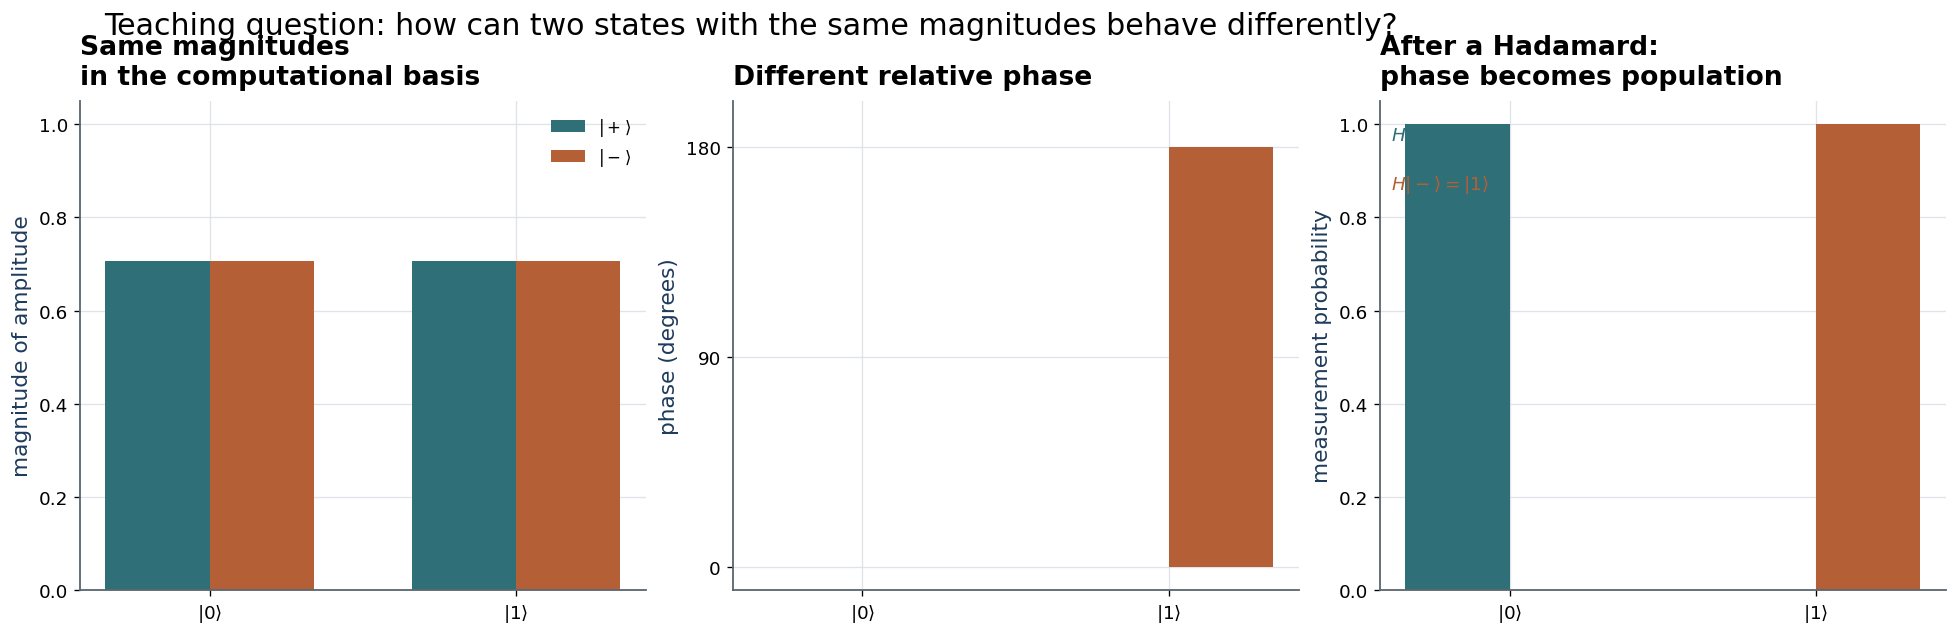

In [52]:
def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


def probability_distribution(state):
    data = np.asarray(state, dtype=complex)
    return np.abs(data) ** 2


labels = [r'$|0\rangle$', r'$|1\rangle$']
hadamard = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

ket_plus = Statevector([1 / np.sqrt(2), 1 / np.sqrt(2)])
ket_minus = Statevector([1 / np.sqrt(2), -1 / np.sqrt(2)])

plus_after_h = Statevector(hadamard @ ket_plus.data)
minus_after_h = Statevector(hadamard @ ket_minus.data)

x = np.arange(len(labels))
width = 0.34

fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.0), constrained_layout=True)

axes[0].bar(x - width / 2, np.abs(ket_plus.data), width=width, color=COLORS['teal'], label=r'$|+\rangle$')
axes[0].bar(x + width / 2, np.abs(ket_minus.data), width=width, color=COLORS['rust'], label=r'$|-\rangle$')
axes[0].set_xticks(x, labels)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('magnitude of amplitude')
axes[0].set_title('Same magnitudes\nin the computational basis', loc='left')
axes[0].legend(fontsize=10)

axes[1].bar(x - width / 2, phase_degrees(ket_plus.data), width=width, color=COLORS['teal'])
axes[1].bar(x + width / 2, phase_degrees(ket_minus.data), width=width, color=COLORS['rust'])
axes[1].set_xticks(x, labels)
axes[1].set_ylim(-10, 200)
axes[1].set_yticks([0, 90, 180])
axes[1].set_ylabel('phase (degrees)')
axes[1].set_title('Different relative phase', loc='left')

axes[2].bar(x - width / 2, probability_distribution(plus_after_h.data), width=width, color=COLORS['teal'])
axes[2].bar(x + width / 2, probability_distribution(minus_after_h.data), width=width, color=COLORS['rust'])
axes[2].set_xticks(x, labels)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('measurement probability')
axes[2].set_title('After a Hadamard:\nphase becomes population', loc='left')

axes[2].text(0.02, 0.92, r'$H|+\rangle = |0\rangle$', transform=axes[2].transAxes, color=COLORS['teal'], fontsize=11)
axes[2].text(0.02, 0.82, r'$H|-\rangle = |1\rangle$', transform=axes[2].transAxes, color=COLORS['rust'], fontsize=11)

fig.suptitle('Teaching question: how can two states with the same magnitudes behave differently?', x=0.05, ha='left', y=1.03)
plt.show()


The first phase visual shows the general mechanism: changing relative phase changes whether contributions add or cancel.

The second phase visual makes the quantum lesson sharper:
- $|+\rangle$ and $|-\rangle$ have the same computational-basis magnitude profile,
- but their relative phases differ,
- and a later basis change converts that phase difference into a directly measurable difference.

This is the exact bridge we need for QFT. The QFT is valuable not because it ignores phase, but because it reorganizes quantum states in a way that makes **phase structure readable**.

> **Takeaway:** In quantum computing, phase is a real computational resource. It may be hidden from one immediate measurement, but gates and basis changes can convert phase patterns into observable outcome patterns. That is why a Fourier-style quantum transformation can be algorithmically useful.

## 4. What QFT Does

**Concept question:** What actually changes when we apply the Quantum Fourier Transform?

The QFT is a **change of basis** on an $N = 2^n$ dimensional quantum state space. It does not look at a list of classical samples and return a classical spectrum. Instead, it reorganizes a quantum state so that information previously stored in computational-basis indexing becomes visible as a **structured pattern of relative phases**.

That is the point to keep in focus. The QFT is not best described as "a quantum FFT" and then left mysterious. The more useful description is:

> The QFT converts computational-basis labels into phase-structured superpositions.

For a basis state $|x\rangle$, the standard definition is
$$
\mathrm{QFT}_N |x\rangle = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} e^{2\pi i xy/N} |y\rangle.
$$

For a general state
$$
|\psi\rangle = \sum_{x=0}^{N-1} \alpha_x |x\rangle,
$$
the output amplitudes become phase-sensitive sums,
$$
\tilde{\alpha}_y = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} \alpha_x e^{2\pi i xy/N}.
$$

So the QFT does two things at once:
- it spreads local basis information across the whole register,
- and it organizes that spread using a highly structured phase rule.

The visual below uses one 3-qubit basis state as an example. The input is concentrated on one computational basis label. After QFT, the output has equal magnitude on every basis state, but the **phase pattern is no longer trivial**. That phase pattern is the content.

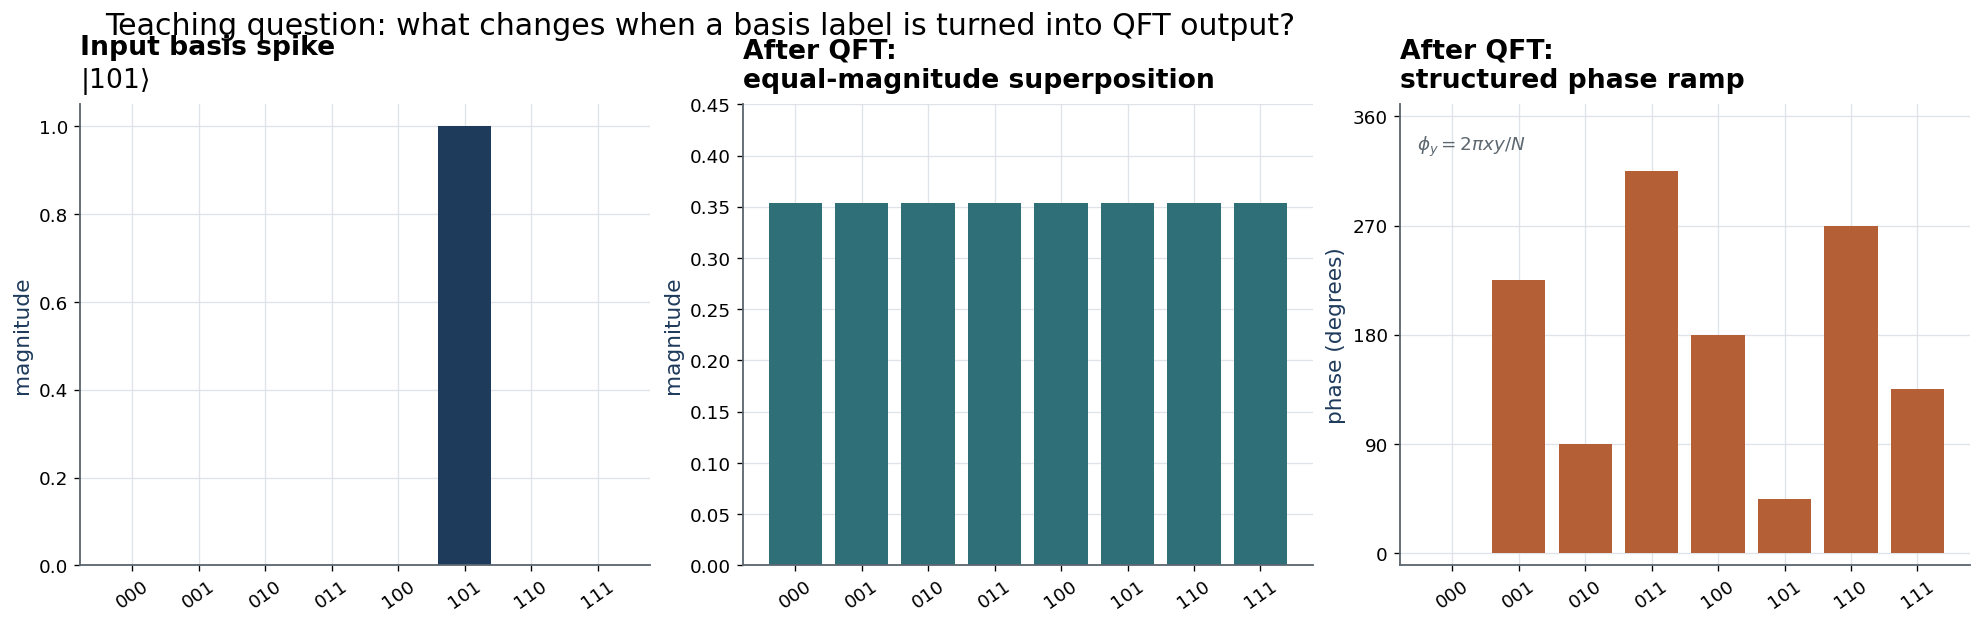

In [53]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def qft_matrix(num_qubits):
    dimension = 2**num_qubits
    omega = np.exp(2j * np.pi / dimension)
    return np.array(
        [[omega ** (row * col) for col in range(dimension)] for row in range(dimension)],
        dtype=complex,
    ) / np.sqrt(dimension)


def qft_basis_state(num_qubits, index):
    return Statevector(qft_matrix(num_qubits) @ basis_ket(num_qubits, index))


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


num_qubits = 3
input_index = 5
labels_3 = computational_labels(num_qubits)

input_state = basis_ket(num_qubits, input_index)
output_state = qft_basis_state(num_qubits, input_index).data
x = np.arange(len(labels_3))

fig, axes = plt.subplots(1, 3, figsize=(16.4, 4.9), constrained_layout=True)

axes[0].bar(x, np.abs(input_state), color=COLORS['navy'])
axes[0].set_xticks(x, labels_3, rotation=35)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('magnitude')
axes[0].set_title(f"Input basis spike\n$|{labels_3[input_index]}\\rangle$", loc='left')

axes[1].bar(x, np.abs(output_state), color=COLORS['teal'])
axes[1].set_xticks(x, labels_3, rotation=35)
axes[1].set_ylim(0, 0.45)
axes[1].set_ylabel('magnitude')
axes[1].set_title('After QFT:\nequal-magnitude superposition', loc='left')

axes[2].bar(x, phase_degrees(output_state), color=COLORS['rust'])
axes[2].set_xticks(x, labels_3, rotation=35)
axes[2].set_ylim(-10, 370)
axes[2].set_yticks([0, 90, 180, 270, 360])
axes[2].set_ylabel('phase (degrees)')
axes[2].set_title('After QFT:\nstructured phase ramp', loc='left')
axes[2].text(0.03, 0.9, r'$\phi_y = 2\pi xy/N$', transform=axes[2].transAxes, color=COLORS['gray'], fontsize=11)

fig.suptitle('Teaching question: what changes when a basis label is turned into QFT output?', x=0.05, ha='left', y=1.03)
plt.show()


The conceptual shift is now visible:
- before QFT, the information is concentrated in **which basis label** is occupied,
- after QFT, the information is carried by a **global phase pattern** spread across all labels.

> **Takeaway:** The QFT does not merely "make a superposition." It creates a very specific superposition whose main structure lies in relative phase. That phase structure is what later algorithms try to exploit or decode.

## 5. How QFT Acts on Basis States

**Concept question:** What does the QFT do to a concrete computational basis state like $|01\rangle$ or $|101\rangle$?

For basis states, the QFT action is especially clean:
- every output basis state gets the **same magnitude** $1/\sqrt{N}$,
- what changes from one input $|x\rangle$ to another is the **phase attached to each output label $|y\rangle$**.

That means the basis-state action is not mainly a story about where probability mass moves. It is a story about **which phase ramp appears across the output labels**.

For 2 qubits ($N=4$), a few examples already show the pattern:
$$
\mathrm{QFT}_4|00\rangle = \frac{1}{2}\big(|00\rangle + |01\rangle + |10\rangle + |11\rangle\big),
$$
$$
\mathrm{QFT}_4|01\rangle = \frac{1}{2}\big(|00\rangle + i|01\rangle - |10\rangle - i|11\rangle\big),
$$
$$
\mathrm{QFT}_4|10\rangle = \frac{1}{2}\big(|00\rangle - |01\rangle + |10\rangle - |11\rangle\big).
$$

The magnitudes are identical in all three cases. The difference is entirely in the phase ordering.

That is why phase is the key content here. Different basis inputs become different **phase-coded templates**.

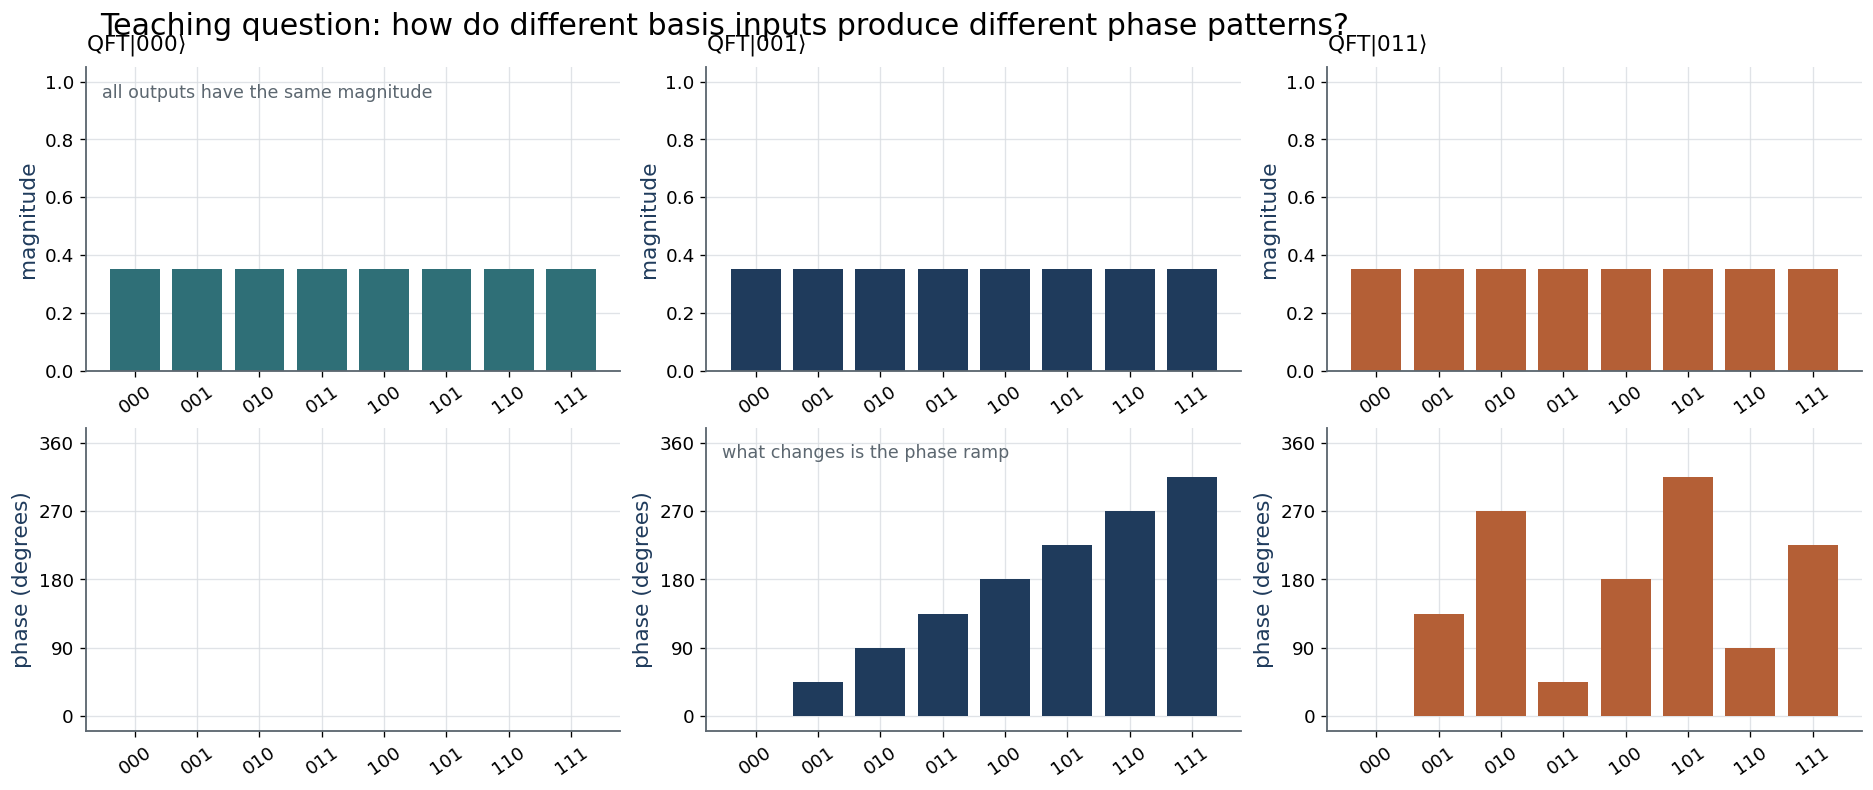

In [54]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def qft_matrix(num_qubits):
    dimension = 2**num_qubits
    omega = np.exp(2j * np.pi / dimension)
    return np.array(
        [[omega ** (row * col) for col in range(dimension)] for row in range(dimension)],
        dtype=complex,
    ) / np.sqrt(dimension)


def qft_basis_state(num_qubits, index):
    return Statevector(qft_matrix(num_qubits) @ basis_ket(num_qubits, index))


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


def plot_state_magnitude_phase(ax_mag, ax_phase, state, labels, *, color=COLORS['navy'], title=''):
    data = np.asarray(state, dtype=complex)
    x = np.arange(len(labels))

    ax_mag.bar(x, np.abs(data), color=color)
    ax_mag.set_xticks(x, labels, rotation=35)
    ax_mag.set_ylim(0, 1.05)
    ax_mag.set_ylabel('magnitude')
    ax_mag.set_title(title, loc='left', fontsize=13)

    ax_phase.bar(x, phase_degrees(data), color=color)
    ax_phase.set_xticks(x, labels, rotation=35)
    ax_phase.set_ylim(-20, 380)
    ax_phase.set_yticks([0, 90, 180, 270, 360])
    ax_phase.set_ylabel('phase (degrees)')


sample_indices = [0, 1, 3]
labels_3 = computational_labels(3)
fig, axes = plt.subplots(2, len(sample_indices), figsize=(15.5, 6.3), constrained_layout=True)

for column, index in enumerate(sample_indices):
    state = qft_basis_state(3, index).data
    plot_state_magnitude_phase(
        axes[0, column],
        axes[1, column],
        state,
        labels_3,
        color=[COLORS['teal'], COLORS['navy'], COLORS['rust']][column],
        title=fr"$\mathrm{{QFT}}|{labels_3[index]}\rangle$",
    )

axes[0, 0].text(0.03, 0.9, 'all outputs have the same magnitude', transform=axes[0, 0].transAxes, fontsize=10.5, color=COLORS['gray'])
axes[1, 1].text(0.03, 0.9, 'what changes is the phase ramp', transform=axes[1, 1].transAxes, fontsize=10.5, color=COLORS['gray'])

fig.suptitle('Teaching question: how do different basis inputs produce different phase patterns?', x=0.05, ha='left', y=1.02)
plt.show()


This gallery makes three facts visible at once:
- the QFT output of a basis state always has a flat magnitude profile,
- different inputs do **not** mainly differ by amplitude size,
- the distinguishing information is the ordered phase pattern across the basis labels.

For $|000\rangle$, the phase pattern is flat. For $|001\rangle$, the phase increases steadily. For $|011\rangle$, the ramp is steeper and wraps around the circle faster. In that sense, different basis labels correspond to different phase frequencies.

> **Takeaway:** When the input is a computational basis state, the QFT turns "which label is occupied" into "which phase ramp appears across the output basis."

## 6. QFT Circuit Anatomy: Hadamards, Controlled Phase Gates, Swaps

**Concept question:** Why does the standard QFT circuit have exactly these gate types, in exactly this kind of order?

The standard QFT circuit is structured, not arbitrary. Each gate class has a specific job:
- **Hadamards** create local superposition so each qubit can carry a phase-sensitive mixture of $|0\rangle$ and $|1\rangle$.
- **Controlled phase gates** imprint relative phases that depend on more significant and less significant input bits.
- **Swaps** reverse the output order so the final register matches the conventional QFT ordering.

A useful way to think about the basis-state action is the product-state form. For an input bit string $x_1x_2\dots x_n$, the QFT output can be written as a tensor product of one-qubit phase states whose phases depend on binary fractions built from the input bits. Schematically,
$$
\mathrm{QFT}|x_1x_2\dots x_n\rangle = \frac{1}{2^{n/2}}
\big(|0\rangle + e^{2\pi i\,0.x_n}|1\rangle\big)
\big(|0\rangle + e^{2\pi i\,0.x_{n-1}x_n}|1\rangle\big)
\cdots
\big(|0\rangle + e^{2\pi i\,0.x_1x_2\dots x_n}|1\rangle\big),
$$
up to the conventional output ordering handled by swaps.

That expression explains the gate pattern:
- each qubit needs a Hadamard to create its local $|0\rangle + e^{i\phi}|1\rangle$ form,
- and then it needs controlled phase rotations from other qubits to set the correct binary-fraction phase.

The build-up below uses a 2-qubit example so each stage remains visible.

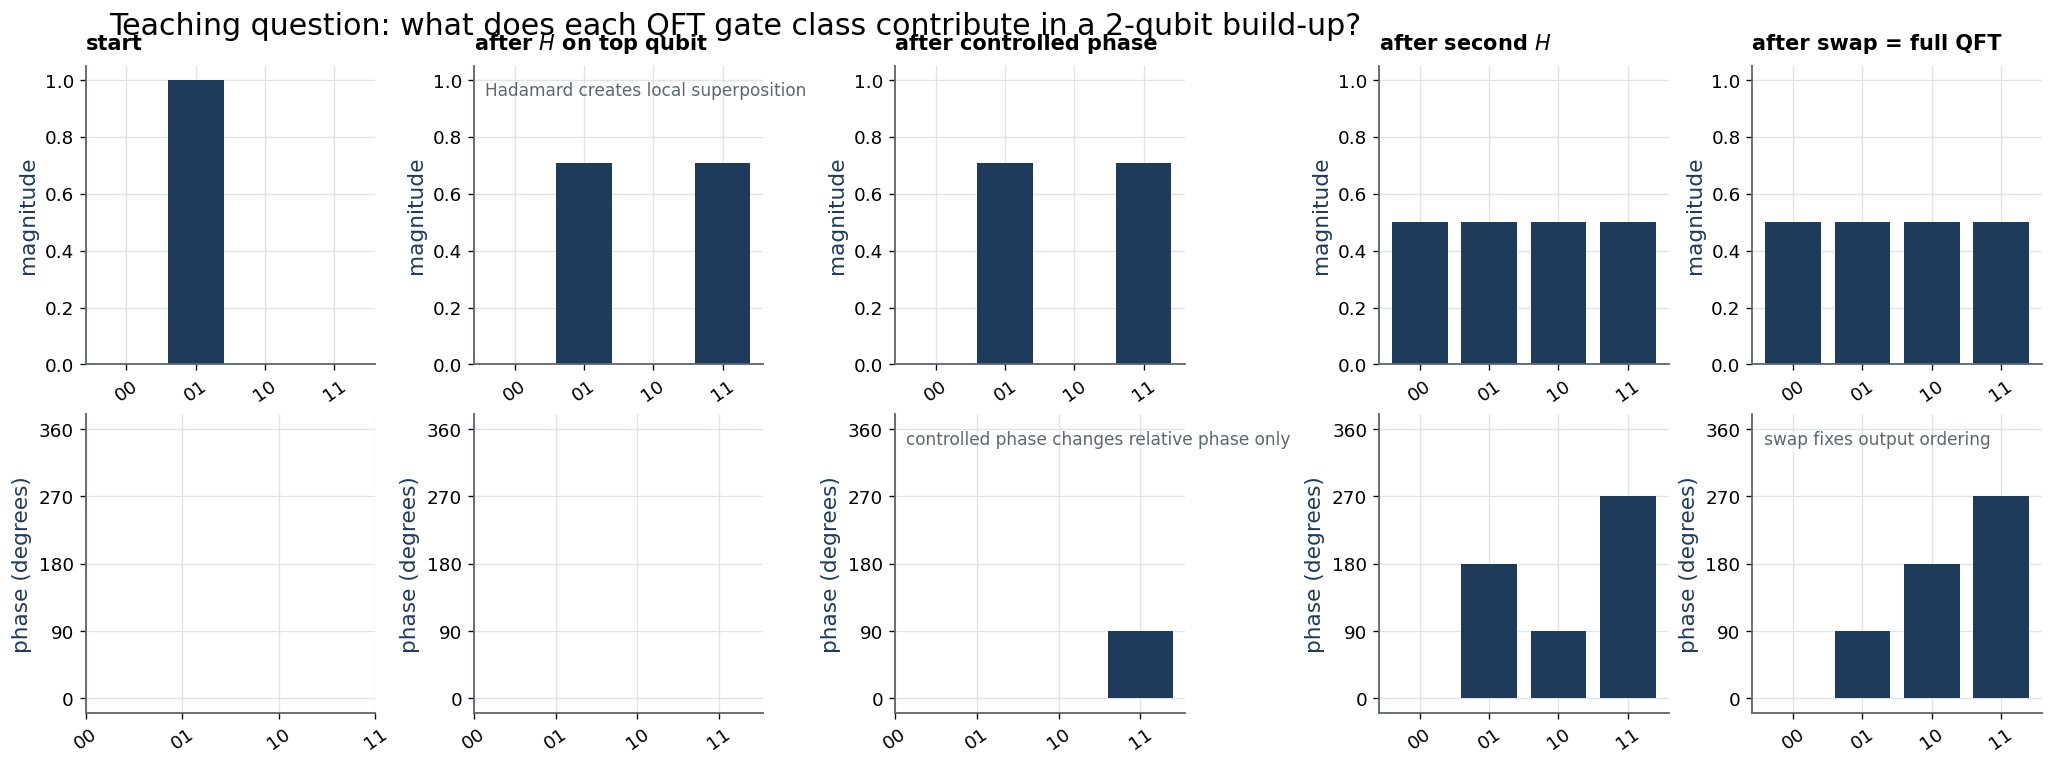

In [55]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


def plot_state_magnitude_phase(ax_mag, ax_phase, state, labels, *, color=COLORS['navy'], title=''):
    data = np.asarray(state, dtype=complex)
    x = np.arange(len(labels))

    ax_mag.bar(x, np.abs(data), color=color)
    ax_mag.set_xticks(x, labels, rotation=35)
    ax_mag.set_ylim(0, 1.05)
    ax_mag.set_ylabel('magnitude')
    ax_mag.set_title(title, loc='left', fontsize=12.5)

    ax_phase.bar(x, phase_degrees(data), color=color)
    ax_phase.set_xticks(x, labels, rotation=35)
    ax_phase.set_ylim(-20, 380)
    ax_phase.set_yticks([0, 90, 180, 270, 360])
    ax_phase.set_ylabel('phase (degrees)')


labels_2 = computational_labels(2)
input_index_2 = 1
initial_state_2 = Statevector(basis_ket(2, input_index_2))

qc_step_1 = QuantumCircuit(2)
qc_step_1.h(1)

qc_step_2 = qc_step_1.copy()
qc_step_2.cp(np.pi / 2, 0, 1)

qc_step_3 = qc_step_2.copy()
qc_step_3.h(0)

qc_step_4 = qc_step_3.copy()
qc_step_4.swap(0, 1)

stage_specs = [
    ('start', initial_state_2),
    ('after $H$ on top qubit', initial_state_2.evolve(qc_step_1)),
    ('after controlled phase', initial_state_2.evolve(qc_step_2)),
    ('after second $H$', initial_state_2.evolve(qc_step_3)),
    ('after swap = full QFT', initial_state_2.evolve(qc_step_4)),
]

fig, axes = plt.subplots(2, len(stage_specs), figsize=(17.0, 6.1), constrained_layout=True)

for column, (title, state) in enumerate(stage_specs):
    plot_state_magnitude_phase(
        axes[0, column],
        axes[1, column],
        state.data,
        labels_2,
        color=COLORS['navy'],
        title=title,
    )

axes[0, 1].text(0.04, 0.9, 'Hadamard creates local superposition', transform=axes[0, 1].transAxes, fontsize=10.2, color=COLORS['gray'])
axes[1, 2].text(0.04, 0.9, 'controlled phase changes relative phase only', transform=axes[1, 2].transAxes, fontsize=10.2, color=COLORS['gray'])
axes[1, 4].text(0.04, 0.9, 'swap fixes output ordering', transform=axes[1, 4].transAxes, fontsize=10.2, color=COLORS['gray'])

fig.suptitle('Teaching question: what does each QFT gate class contribute in a 2-qubit build-up?', x=0.05, ha='left', y=1.02)
plt.show()


2-qubit QFT circuit


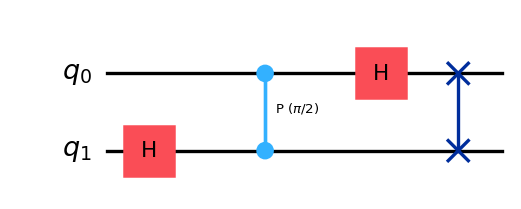

3-qubit QFT circuit


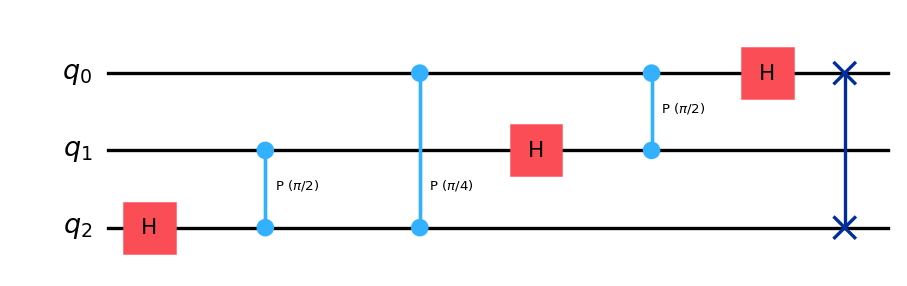

In [56]:
def manual_qft_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits, name=f'QFT_{num_qubits}')
    for target in range(num_qubits - 1, -1, -1):
        qc.h(target)
        for control in range(target - 1, -1, -1):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
    for qubit in range(num_qubits // 2):
        qc.swap(qubit, num_qubits - 1 - qubit)
    return qc


qft_2 = manual_qft_circuit(2)
qft_3 = manual_qft_circuit(3)

print('2-qubit QFT circuit')
display(qft_2.draw('mpl'))

print('3-qubit QFT circuit')
display(qft_3.draw('mpl'))


The 2-qubit and 3-qubit circuit diagrams now read naturally:
- the first qubit to be processed gets a Hadamard and then receives several controlled phase corrections,
- later qubits receive fewer corrections because they depend on shorter binary-fraction tails,
- the final swaps reverse the order produced by this staged construction.

> **Takeaway:** The QFT circuit is a phase-engineering circuit. Hadamards create the local superpositions, controlled phase gates set the correct relative phases, and swaps restore the conventional output order.

## 7. Inverse QFT

**Concept question:** Why is the inverse QFT more than a formal inverse on paper?

Mathematically, the inverse QFT is the adjoint transformation,
$$
\mathrm{QFT}^{-1} = \mathrm{QFT}^{\dagger}.
$$
It reverses the forward map: if the QFT turns a basis label into a structured phase pattern, the inverse QFT turns the right kind of structured phase pattern back into a sharp computational-basis signal.

Circuit-wise, inverse QFT means:
- reverse the gate order,
- replace each controlled phase rotation by its inverse angle,
- keep the swaps because the ordering must also be undone consistently.

This is operationally important. In many algorithms, the useful information is created as a **phase pattern first**. The inverse QFT is then the step that converts that hidden phase information into a basis-state pattern that we can measure.

> **Common misconception:** inverse QFT is not only a cleanup step. In algorithms such as phase estimation, it is the **decoding step** that makes phase information readable in the computational basis.

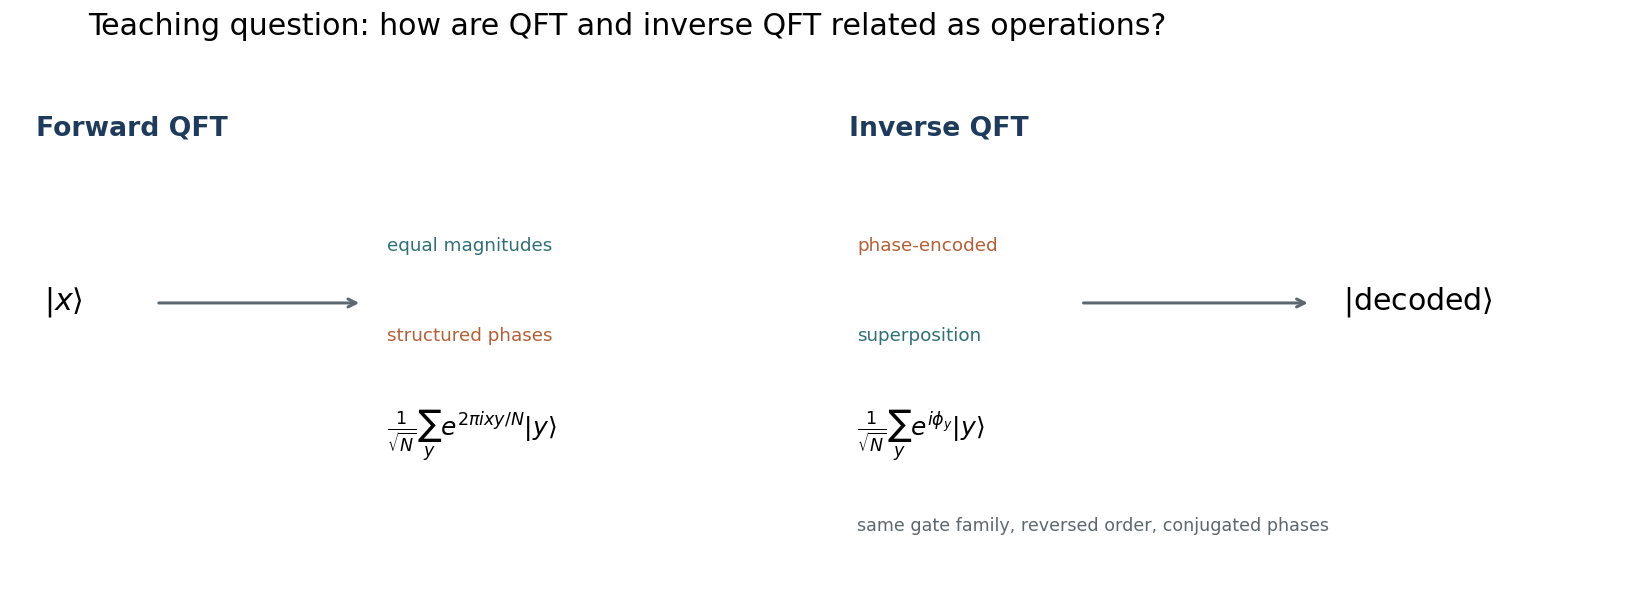

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)

for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].text(0.3, 4.2, 'Forward QFT', fontsize=16, color=COLORS['navy'], fontweight='semibold')
axes[0].text(0.4, 2.55, r'$|x\rangle$', fontsize=18)
axes[0].annotate('', xy=(4.4, 2.6), xytext=(1.8, 2.6), arrowprops={'arrowstyle': '->', 'linewidth': 1.8, 'color': COLORS['gray']})
axes[0].text(4.7, 3.1, 'equal magnitudes', fontsize=11, color=COLORS['teal'])
axes[0].text(4.7, 2.25, 'structured phases', fontsize=11, color=COLORS['rust'])
axes[0].text(4.7, 1.35, r'$\frac{1}{\sqrt{N}}\sum_y e^{2\pi ixy/N}|y\rangle$', fontsize=15)

axes[1].text(0.3, 4.2, 'Inverse QFT', fontsize=16, color=COLORS['navy'], fontweight='semibold')
axes[1].text(0.4, 3.1, 'phase-encoded', fontsize=11, color=COLORS['rust'])
axes[1].text(0.4, 2.25, 'superposition', fontsize=11, color=COLORS['teal'])
axes[1].text(0.4, 1.35, r'$\frac{1}{\sqrt{N}}\sum_y e^{i\phi_y}|y\rangle$', fontsize=15)
axes[1].annotate('', xy=(6.1, 2.6), xytext=(3.2, 2.6), arrowprops={'arrowstyle': '->', 'linewidth': 1.8, 'color': COLORS['gray']})
axes[1].text(6.5, 2.55, r'$|\mathrm{decoded}\rangle$', fontsize=18)
axes[1].text(0.4, 0.45, 'same gate family, reversed order, conjugated phases', fontsize=10.5, color=COLORS['gray'])

fig.suptitle('Teaching question: how are QFT and inverse QFT related as operations?', x=0.05, ha='left')
plt.show()


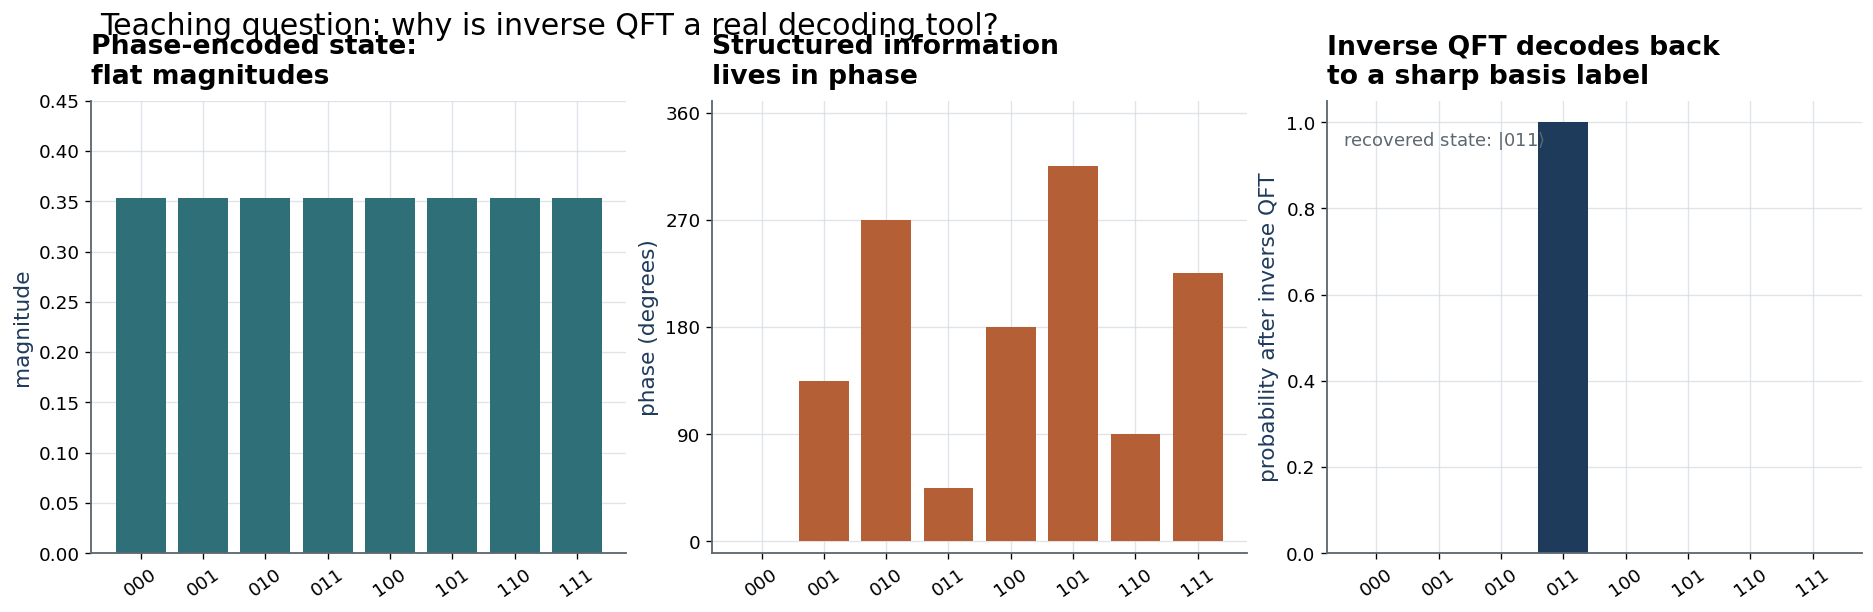

In [58]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def qft_matrix(num_qubits):
    dimension = 2**num_qubits
    omega = np.exp(2j * np.pi / dimension)
    return np.array(
        [[omega ** (row * col) for col in range(dimension)] for row in range(dimension)],
        dtype=complex,
    ) / np.sqrt(dimension)


def qft_basis_state(num_qubits, index):
    return Statevector(qft_matrix(num_qubits) @ basis_ket(num_qubits, index))


def manual_qft_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits, name=f'QFT_{num_qubits}')
    for target in range(num_qubits - 1, -1, -1):
        qc.h(target)
        for control in range(target - 1, -1, -1):
            angle = np.pi / (2 ** (target - control))
            qc.cp(angle, control, target)
    for qubit in range(num_qubits // 2):
        qc.swap(qubit, num_qubits - 1 - qubit)
    return qc


def manual_iqft_circuit(num_qubits):
    return manual_qft_circuit(num_qubits).inverse()


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


def probability_distribution(state):
    data = np.asarray(state, dtype=complex)
    return np.abs(data) ** 2


encoded_index = 3
encoded_state = qft_basis_state(3, encoded_index)
decoded_state = encoded_state.evolve(manual_iqft_circuit(3))
labels_3 = computational_labels(3)
x = np.arange(len(labels_3))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)

axes[0].bar(x, np.abs(encoded_state.data), color=COLORS['teal'])
axes[0].set_xticks(x, labels_3, rotation=35)
axes[0].set_ylim(0, 0.45)
axes[0].set_ylabel('magnitude')
axes[0].set_title('Phase-encoded state:\nflat magnitudes', loc='left')

axes[1].bar(x, phase_degrees(encoded_state.data), color=COLORS['rust'])
axes[1].set_xticks(x, labels_3, rotation=35)
axes[1].set_ylim(-10, 370)
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].set_ylabel('phase (degrees)')
axes[1].set_title('Structured information\nlives in phase', loc='left')

axes[2].bar(x, probability_distribution(decoded_state.data), color=COLORS['navy'])
axes[2].set_xticks(x, labels_3, rotation=35)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('probability after inverse QFT')
axes[2].set_title('Inverse QFT decodes back\nto a sharp basis label', loc='left')
axes[2].text(0.03, 0.9, fr"recovered state: $|{labels_3[encoded_index]}\rangle$", transform=axes[2].transAxes, fontsize=10.8, color=COLORS['gray'])

fig.suptitle('Teaching question: why is inverse QFT a real decoding tool?', x=0.05, ha='left', y=1.03)
plt.show()


The inverse-QFT picture should now feel natural:
- forward QFT turns basis information into a global phase template,
- inverse QFT reverses that map,
- and in algorithmic settings it can turn phase information into a basis-state pattern that measurement can reveal.

> **Takeaway:** QFT and inverse QFT are a matched pair: one writes information into structured phase, and the other can decode structured phase back into computational-basis information.

## 8. Hands-on: Applying QFT to Simple States

**Concept question:** What does the QFT do to actual states we can inspect directly?

This is the point where QFT should stop feeling abstract. We will apply it to a few small 3-qubit states and inspect the outputs on purpose.

The examples below are chosen to highlight different situations:
- a single computational basis state,
- a simple equal superposition of two nearby basis states,
- a two-component state with the same magnitudes as the previous example but a different relative phase.

For each example, ask two questions:
1. What changed in the magnitude pattern?
2. What changed in the phase pattern?

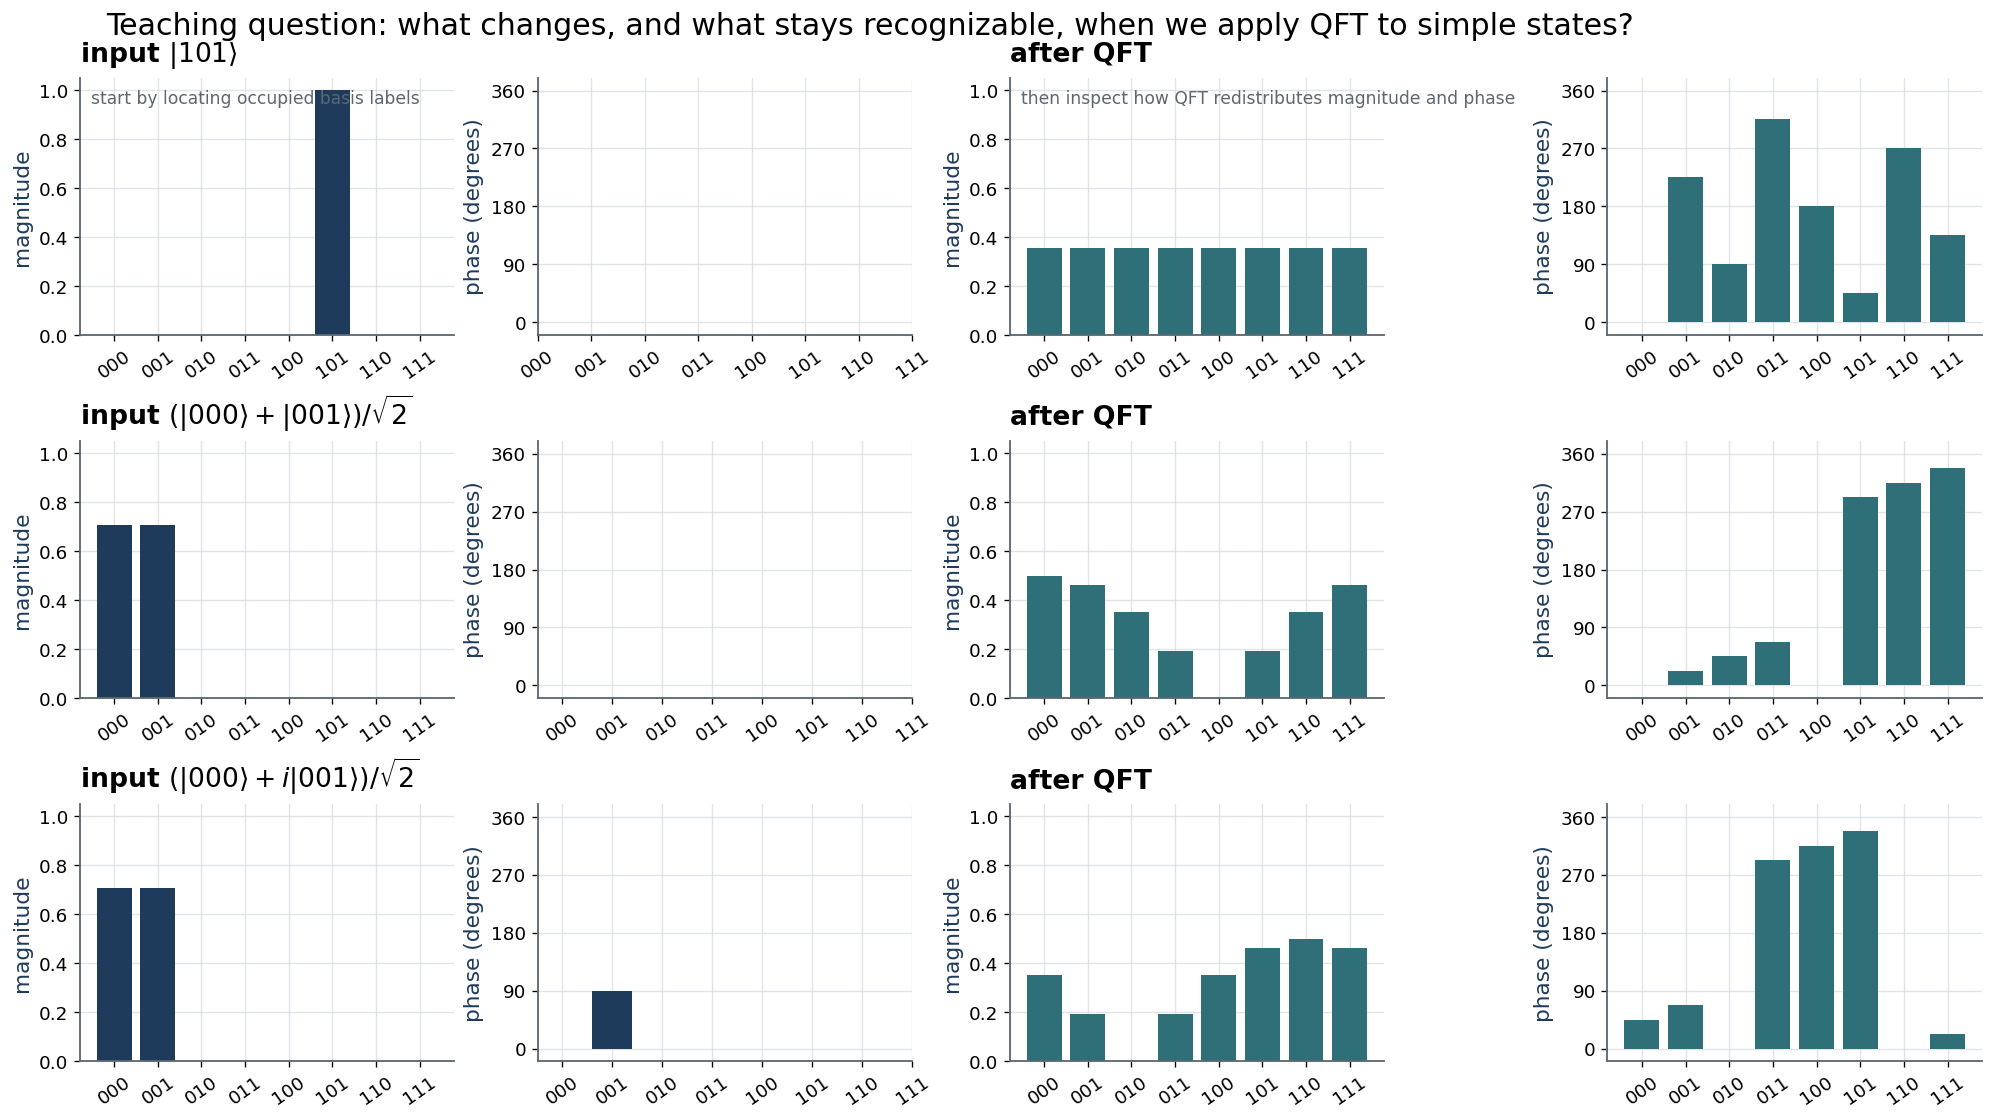

In [59]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


# We keep this example fully local: build the 3-qubit QFT circuit in the cell.
labels_3 = computational_labels(3)
explicit_qft_3 = QuantumCircuit(3, name='QFT_3_for_examples')
explicit_qft_3.h(2)
explicit_qft_3.cp(np.pi / 2, 1, 2)
explicit_qft_3.cp(np.pi / 4, 0, 2)
explicit_qft_3.h(1)
explicit_qft_3.cp(np.pi / 2, 0, 1)
explicit_qft_3.h(0)
explicit_qft_3.swap(0, 2)

# Example 1: one computational basis state.
state_basis = Statevector.from_label('101')

# Example 2: a simple equal superposition of two nearby basis states.
state_pair = Statevector((basis_ket(3, 0) + basis_ket(3, 1)) / np.sqrt(2))

# Example 3: same input magnitudes as Example 2, but with a different relative phase.
state_pair_phase = Statevector((basis_ket(3, 0) + 1j * basis_ket(3, 1)) / np.sqrt(2))

simple_examples = [
    (r'$|101\rangle$', state_basis),
    (r'$(|000\rangle + |001\rangle)/\sqrt{2}$', state_pair),
    (r'$(|000\rangle + i|001\rangle)/\sqrt{2}$', state_pair_phase),
]

fig, axes = plt.subplots(len(simple_examples), 4, figsize=(16.5, 9.0), constrained_layout=True)

for row, (title, input_state) in enumerate(simple_examples):
    # Apply the explicit QFT circuit to the chosen input state.
    output_state = input_state.evolve(explicit_qft_3)

    # Plot input magnitudes.
    axes[row, 0].bar(np.arange(len(labels_3)), np.abs(input_state.data), color=COLORS['navy'])
    axes[row, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 0].set_ylim(0, 1.05)
    axes[row, 0].set_ylabel('magnitude')
    axes[row, 0].set_title(f'input {title}', loc='left')

    # Plot input phases separately so students can see where phase is already present.
    axes[row, 1].bar(np.arange(len(labels_3)), phase_degrees(input_state.data), color=COLORS['navy'])
    axes[row, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 1].set_ylim(-20, 380)
    axes[row, 1].set_yticks([0, 90, 180, 270, 360])
    axes[row, 1].set_ylabel('phase (degrees)')

    # Plot output magnitudes after QFT.
    axes[row, 2].bar(np.arange(len(labels_3)), np.abs(output_state.data), color=COLORS['teal'])
    axes[row, 2].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 2].set_ylim(0, 1.05)
    axes[row, 2].set_ylabel('magnitude')
    axes[row, 2].set_title('after QFT', loc='left')

    # Plot output phases after QFT.
    axes[row, 3].bar(np.arange(len(labels_3)), phase_degrees(output_state.data), color=COLORS['teal'])
    axes[row, 3].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 3].set_ylim(-20, 380)
    axes[row, 3].set_yticks([0, 90, 180, 270, 360])
    axes[row, 3].set_ylabel('phase (degrees)')

axes[0, 0].text(0.03, 0.9, 'start by locating occupied basis labels', transform=axes[0, 0].transAxes, fontsize=10.3, color=COLORS['gray'])
axes[0, 2].text(0.03, 0.9, 'then inspect how QFT redistributes magnitude and phase', transform=axes[0, 2].transAxes, fontsize=10.3, color=COLORS['gray'])

fig.suptitle('Teaching question: what changes, and what stays recognizable, when we apply QFT to simple states?', x=0.05, ha='left', y=1.02)
plt.show()


A few patterns should stand out immediately:
- For the basis state $|101\rangle$, QFT produces the familiar flat-magnitude output with a strong phase ramp.
- For the two-component superposition, QFT no longer gives flat magnitudes everywhere. Interference between the two components creates a nontrivial magnitude profile.
- The last two inputs have the same input magnitudes, but because one uses a relative phase of $1$ and the other uses a relative phase of $i$, the QFT outputs differ visibly.

> **Takeaway:** Applying QFT to a general state is not only a matter of spreading amplitudes. Relative phase in the input changes how the Fourier components interfere in the output.

### Task 8.1 - Try QFT on your own input state

Choose at least one new 3-qubit state that does **not** appear in the worked example above.

Suggestions:
- one new computational basis state,
- one two-component superposition,
- or one state with a nontrivial relative phase such as $(|000\rangle - i|111\rangle)/\sqrt{2}$.

Your job:
1. build the input state,
2. apply `explicit_qft_3`,
3. inspect magnitudes and phases separately,
4. write a short interpretation: what changed, and what information seems to be carried mainly by phase?


In [60]:
# Your code here
# Reuse explicit_qft_3 from the worked example above, or rebuild it locally if needed.
# Suggested variables: my_input_state, my_output_state.
# Make one magnitude plot and one phase plot, or print the amplitudes clearly.
# Then add 2-3 sentences of interpretation in a new markdown cell below.
pass


## 9. Hands-on: Inspecting Statevectors, Amplitudes, and Phases

**Concept question:** How should we inspect a quantum state so that we do not miss the important information?

For QFT work, inspecting only probabilities is usually not enough. In the code below we will separate:
- amplitude **magnitude**,
- amplitude **phase**.

That separation is not cosmetic. It prevents a common mistake:

> **Common misconception:** if two states have the same magnitude profile, they are "basically the same." For QFT, that is often exactly the wrong conclusion.

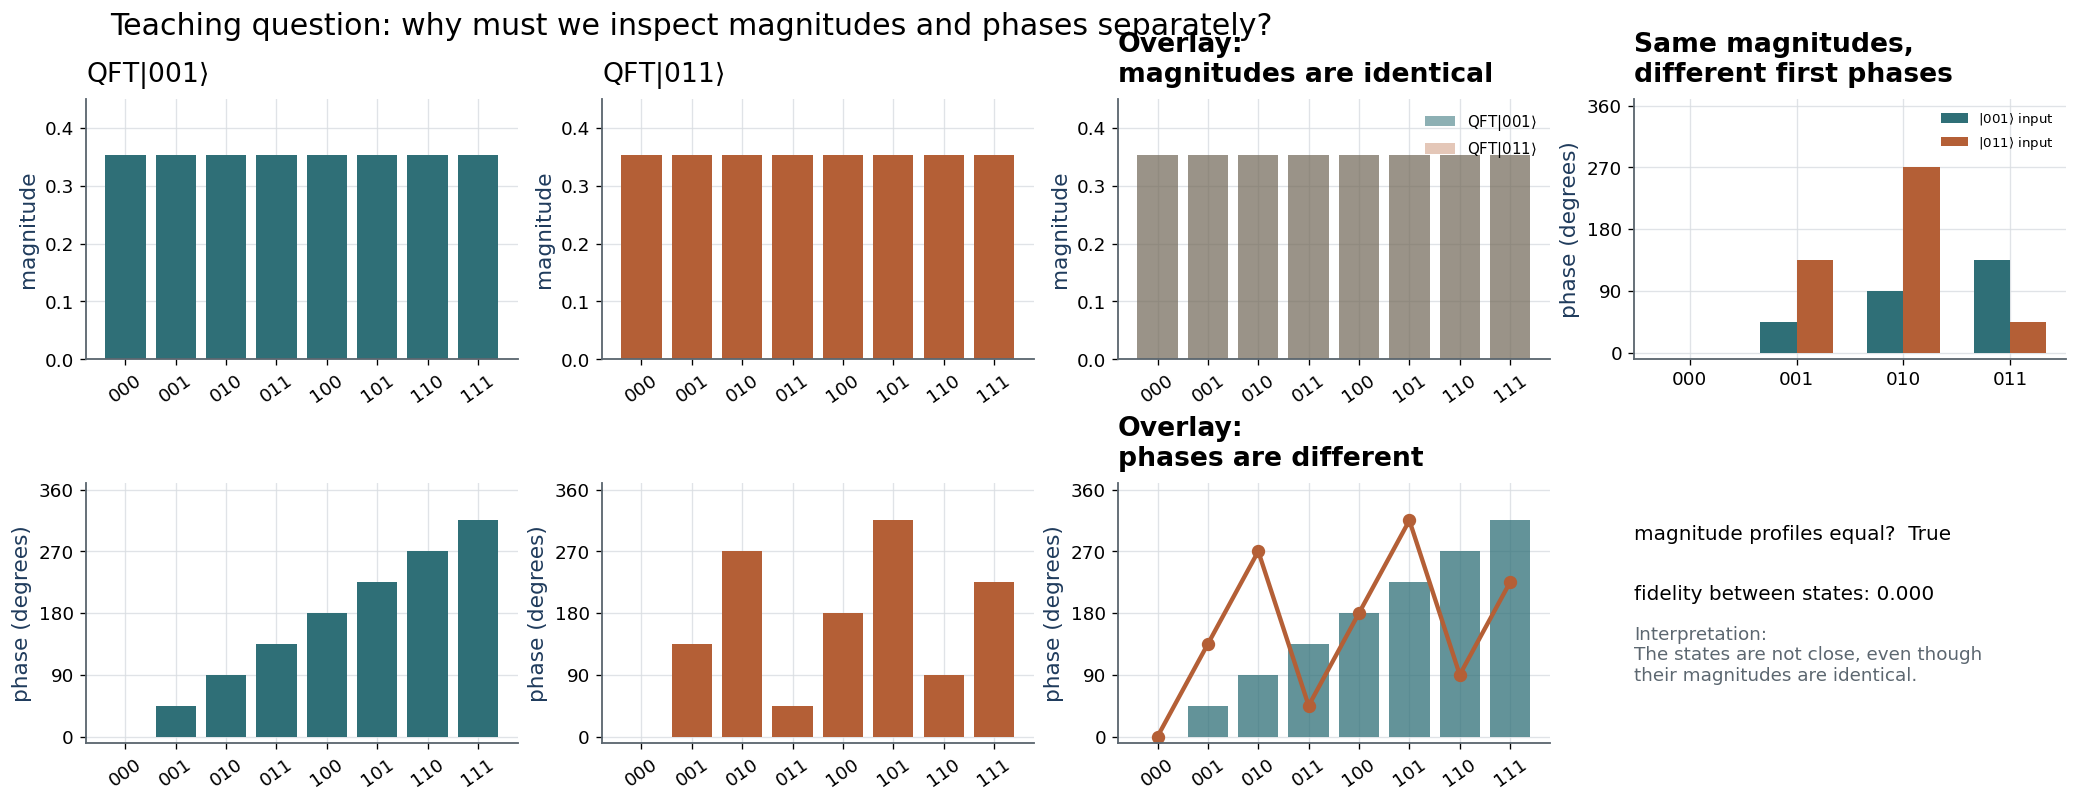

In [61]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


labels_3 = computational_labels(3)

# Rebuild a readable 3-qubit QFT circuit inside the cell so the source is local.
qft_for_inspection = QuantumCircuit(3)
qft_for_inspection.h(2)
qft_for_inspection.cp(np.pi / 2, 1, 2)
qft_for_inspection.cp(np.pi / 4, 0, 2)
qft_for_inspection.h(1)
qft_for_inspection.cp(np.pi / 2, 0, 1)
qft_for_inspection.h(0)
qft_for_inspection.swap(0, 2)

# Apply QFT to two different basis states.
state_a = Statevector.from_label('001').evolve(qft_for_inspection)
state_b = Statevector.from_label('011').evolve(qft_for_inspection)

fig, axes = plt.subplots(2, 4, figsize=(17.2, 6.4), constrained_layout=True)

# First state: magnitudes and phases side by side.
axes[0, 0].bar(np.arange(len(labels_3)), np.abs(state_a.data), color=COLORS['teal'])
axes[0, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 0].set_ylim(0, 0.45)
axes[0, 0].set_ylabel('magnitude')
axes[0, 0].set_title(r'$\mathrm{QFT}|001\rangle$', loc='left')
axes[1, 0].bar(np.arange(len(labels_3)), phase_degrees(state_a.data), color=COLORS['teal'])
axes[1, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 0].set_ylim(-10, 370)
axes[1, 0].set_yticks([0, 90, 180, 270, 360])
axes[1, 0].set_ylabel('phase (degrees)')

# Second state: same style, so the comparison is easy to make.
axes[0, 1].bar(np.arange(len(labels_3)), np.abs(state_b.data), color=COLORS['rust'])
axes[0, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 1].set_ylim(0, 0.45)
axes[0, 1].set_ylabel('magnitude')
axes[0, 1].set_title(r'$\mathrm{QFT}|011\rangle$', loc='left')
axes[1, 1].bar(np.arange(len(labels_3)), phase_degrees(state_b.data), color=COLORS['rust'])
axes[1, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 1].set_ylim(-10, 370)
axes[1, 1].set_yticks([0, 90, 180, 270, 360])
axes[1, 1].set_ylabel('phase (degrees)')

# Overlay the magnitudes to make the equality visually obvious.
axes[0, 2].bar(np.arange(len(labels_3)), np.abs(state_a.data), color=COLORS['teal'], alpha=0.55, label=r'$\mathrm{QFT}|001\rangle$')
axes[0, 2].bar(np.arange(len(labels_3)), np.abs(state_b.data), color=COLORS['rust'], alpha=0.35, label=r'$\mathrm{QFT}|011\rangle$')
axes[0, 2].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 2].set_ylim(0, 0.45)
axes[0, 2].set_ylabel('magnitude')
axes[0, 2].set_title('Overlay:\nmagnitudes are identical', loc='left')
axes[0, 2].legend(fontsize=9)

# Overlay the phases to show where the real difference lives.
axes[1, 2].bar(np.arange(len(labels_3)), phase_degrees(state_a.data), color=COLORS['teal'], alpha=0.75)
axes[1, 2].plot(np.arange(len(labels_3)), phase_degrees(state_b.data), color=COLORS['rust'], marker='o')
axes[1, 2].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 2].set_ylim(-10, 370)
axes[1, 2].set_yticks([0, 90, 180, 270, 360])
axes[1, 2].set_ylabel('phase (degrees)')
axes[1, 2].set_title('Overlay:\nphases are different', loc='left')

# Focus on the first few phases numerically, because that is often easier to read than the full plot.
selected_indices = [0, 1, 2, 3]
selected_labels = [labels_3[index] for index in selected_indices]
selected_phases_a = phase_degrees(state_a.data)[selected_indices]
selected_phases_b = phase_degrees(state_b.data)[selected_indices]
width = 0.34
x = np.arange(len(selected_indices))
axes[0, 3].bar(x - width / 2, selected_phases_a, width=width, color=COLORS['teal'], label=r'$|001\rangle$ input')
axes[0, 3].bar(x + width / 2, selected_phases_b, width=width, color=COLORS['rust'], label=r'$|011\rangle$ input')
axes[0, 3].set_xticks(x, selected_labels)
axes[0, 3].set_ylim(-10, 370)
axes[0, 3].set_yticks([0, 90, 180, 270, 360])
axes[0, 3].set_ylabel('phase (degrees)')
axes[0, 3].set_title('Same magnitudes,\ndifferent first phases', loc='left')
axes[0, 3].legend(fontsize=8)

# Summarize the comparison numerically.
fidelity = np.abs(np.vdot(state_a.data, state_b.data)) ** 2
axes[1, 3].axis('off')
axes[1, 3].text(0.0, 0.78, f'magnitude profiles equal?  {np.allclose(np.abs(state_a.data), np.abs(state_b.data))}', fontsize=12)
axes[1, 3].text(0.0, 0.55, f'fidelity between states: {fidelity:.3f}', fontsize=12)
axes[1, 3].text(0.0, 0.24, 'Interpretation:\nThe states are not close, even though\ntheir magnitudes are identical.', fontsize=11, color=COLORS['gray'])

fig.suptitle('Teaching question: why must we inspect magnitudes and phases separately?', x=0.05, ha='left', y=1.02)
plt.show()


This is exactly the kind of inspection habit that QFT work requires. If we only kept the magnitude plots, we would miss the whole distinction between these states.

> **Takeaway:** For QFT outputs, phase is often the distinguishing content. Magnitude plots tell only part of the story.

### Task 9.1 - Find two states with the same magnitudes but different phases

Construct two 3-qubit QFT outputs whose **magnitude profiles match** but whose phases differ.

Your job:
- choose two different basis inputs,
- apply QFT,
- verify that the magnitudes match,
- show that the phases do not,
- compute the fidelity between the two output states.

Finish with one sentence: why is a magnitude-only inspection incomplete?


In [62]:
# Your code here
# Suggested plan:
# 1. Pick two basis states.
# 2. Apply qft_for_inspection or explicit_qft_3.
# 3. Compare np.abs(state_a.data) and np.abs(state_b.data).
# 4. Compare phase_degrees(state_a.data) and phase_degrees(state_b.data).
# 5. Compute fidelity = abs(vdot(a, b))**2.
pass


## 10. Hands-on: Manual 2-Qubit QFT

**Concept question:** Can we build a small QFT circuit by hand and still understand every gate?

Yes. For 2 qubits, the manual construction is short enough to read line by line:
- Hadamard on the top qubit,
- a controlled phase of $\pi/2$,
- Hadamard on the second qubit,
- swap to restore conventional output order.

The next cell constructs that circuit explicitly rather than calling a helper.

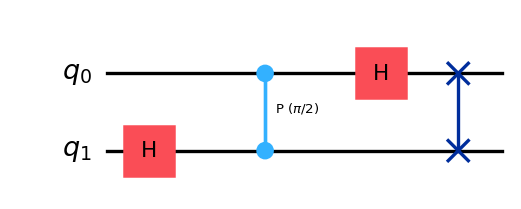

In [63]:
manual_qft_2_explicit = QuantumCircuit(2, name='manual_QFT_2')

# First create the local superposition on the top wire.
manual_qft_2_explicit.h(1)
# Then add the phase correction coming from the lower input bit.
manual_qft_2_explicit.cp(np.pi / 2, 0, 1)
# Now create the phase-sensitive state on the second wire.
manual_qft_2_explicit.h(0)
# Finally swap the wires to match the conventional QFT output order.
manual_qft_2_explicit.swap(0, 1)

display(manual_qft_2_explicit.draw('mpl'))


Gate-layer interpretation:
- The first Hadamard starts the phase-sensitive superposition on the top wire.
- The controlled phase makes the top-wire phase depend on the lower input bit.
- The second Hadamard creates the corresponding phase-sensitive state on the other wire.
- The final swap fixes the bit order so the circuit matches the standard QFT convention.

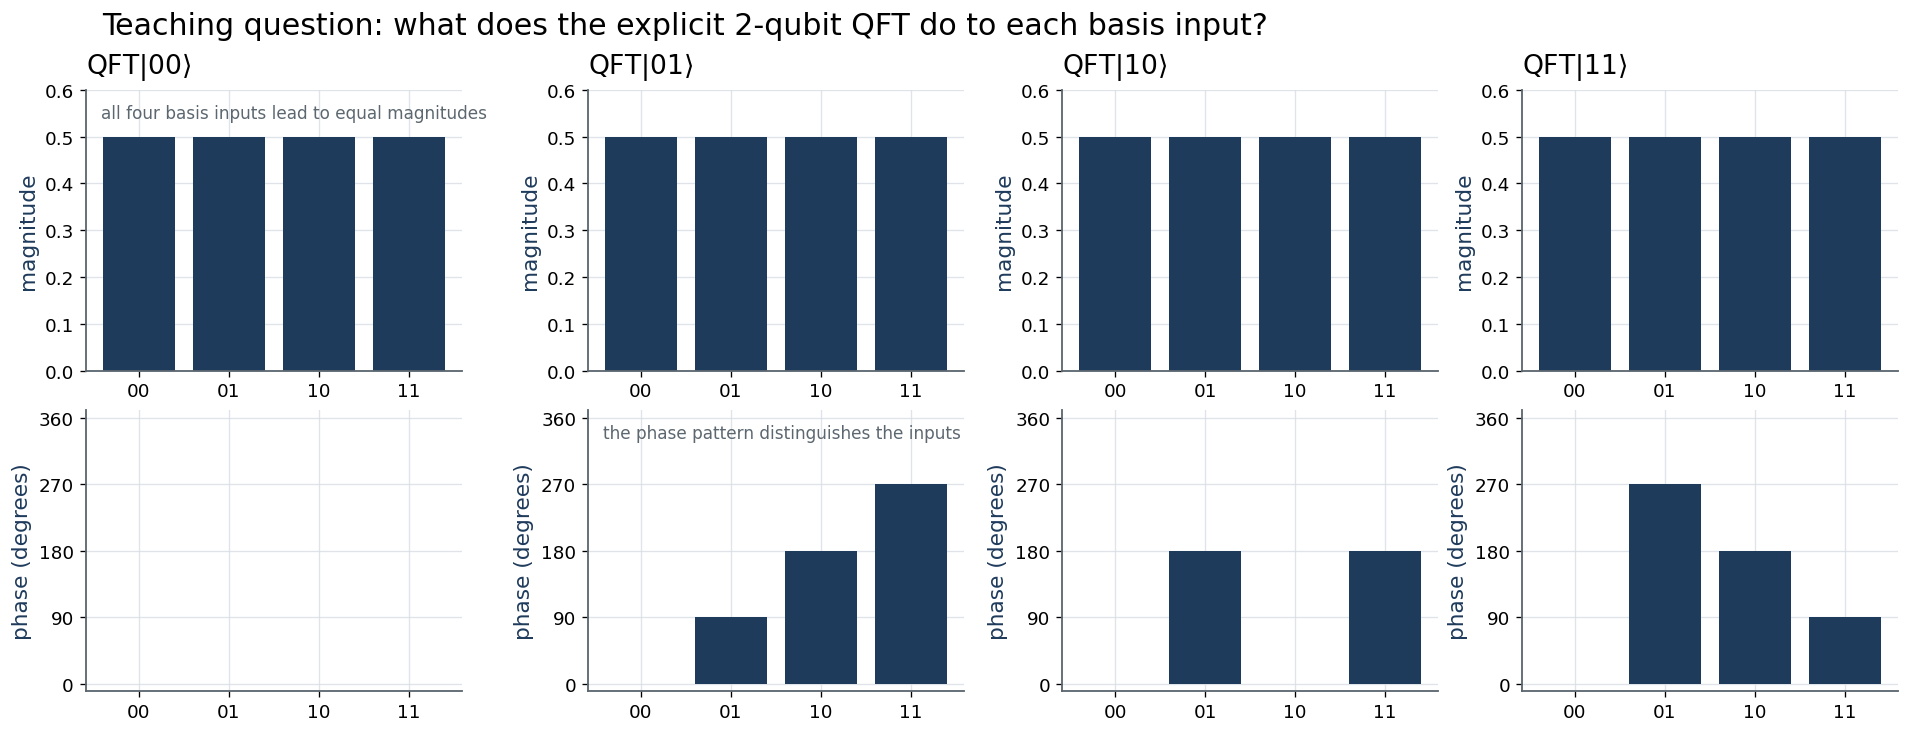

In [64]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


labels_2 = computational_labels(2)
basis_inputs_2 = ['00', '01', '10', '11']
fig, axes = plt.subplots(2, len(basis_inputs_2), figsize=(15.8, 6.0), constrained_layout=True)

for column, label in enumerate(basis_inputs_2):
    # Start from one computational basis input at a time.
    output_state = Statevector.from_label(label).evolve(manual_qft_2_explicit)

    # Plot the magnitudes of the output amplitudes.
    axes[0, column].bar(np.arange(len(labels_2)), np.abs(output_state.data), color=COLORS['navy'])
    axes[0, column].set_xticks(np.arange(len(labels_2)), labels_2)
    axes[0, column].set_ylim(0, 0.6)
    axes[0, column].set_ylabel('magnitude')
    axes[0, column].set_title(fr'$\mathrm{{QFT}}|{label}\rangle$', loc='left')

    # Plot the phases separately: this is what distinguishes the different inputs.
    axes[1, column].bar(np.arange(len(labels_2)), phase_degrees(output_state.data), color=COLORS['navy'])
    axes[1, column].set_xticks(np.arange(len(labels_2)), labels_2)
    axes[1, column].set_ylim(-10, 370)
    axes[1, column].set_yticks([0, 90, 180, 270, 360])
    axes[1, column].set_ylabel('phase (degrees)')

axes[0, 0].text(0.04, 0.9, 'all four basis inputs lead to equal magnitudes', transform=axes[0, 0].transAxes, fontsize=10.1, color=COLORS['gray'])
axes[1, 1].text(0.04, 0.9, 'the phase pattern distinguishes the inputs', transform=axes[1, 1].transAxes, fontsize=10.1, color=COLORS['gray'])

fig.suptitle('Teaching question: what does the explicit 2-qubit QFT do to each basis input?', x=0.05, ha='left')
plt.show()


The manual 2-qubit circuit behaves exactly the way the theory predicted:
- each basis input turns into a flat-magnitude superposition,
- and the phase pattern changes from one input to the next.

> **Takeaway:** A small QFT circuit is fully inspectable by hand. Nothing magical happened here; the circuit simply engineered the right phase pattern.

### Task 10.1 - Rebuild the 2-qubit QFT yourself

Now recreate the 2-qubit QFT **without copying the variable from above**.

Your job:
1. start from an empty 2-qubit circuit,
2. add the gates in the correct order,
3. draw the circuit,
4. test it on one basis input of your choice,
5. explain which gate layer creates superposition and which gate layer changes phase.


In [65]:
# Your code here
# Build a new circuit called student_qft_2.
# Add: H on qubit 1, cp(pi/2, 0, 1), H on qubit 0, then swap(0, 1).
# Test it on one input state with Statevector.from_label(...).
pass


## 11. Hands-on: Manual 3-Qubit QFT

**Concept question:** What changes when we scale the manual construction from 2 qubits to 3?

The basic pattern stays the same, but one new feature becomes more visible: different controlled phase gates carry different angles because different qubits contribute different binary-fraction pieces of the final phase.

We will again write the circuit explicitly and inspect a small number of input states so the output stays readable.

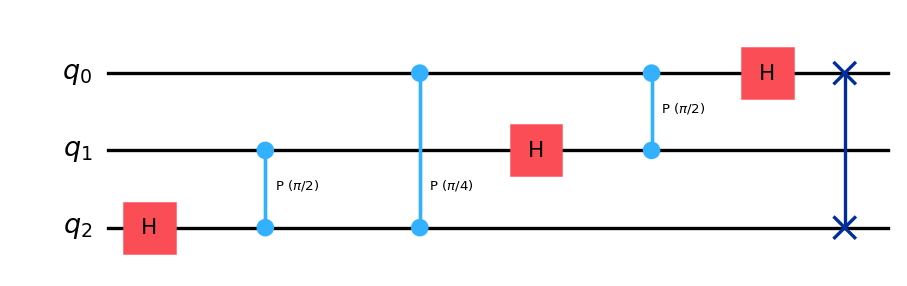

In [66]:
manual_qft_3_explicit = QuantumCircuit(3, name='manual_QFT_3')

# Start with the most significant phase-sensitive output qubit.
manual_qft_3_explicit.h(2)
# Add the binary-fraction phase contributions from the other two input bits.
manual_qft_3_explicit.cp(np.pi / 2, 1, 2)
manual_qft_3_explicit.cp(np.pi / 4, 0, 2)

# Move to the next output qubit and add its shorter-range phase correction.
manual_qft_3_explicit.h(1)
manual_qft_3_explicit.cp(np.pi / 2, 0, 1)

# The last qubit only needs a Hadamard before we fix the output ordering.
manual_qft_3_explicit.h(0)
manual_qft_3_explicit.swap(0, 2)

display(manual_qft_3_explicit.draw('mpl'))


Read the circuit from top to bottom in layers:
- the highest-index wire gets the richest set of phase corrections,
- the middle wire gets fewer,
- the last wire only needs a Hadamard before the final swap layer.

That is exactly what the binary-fraction phase rule predicts.

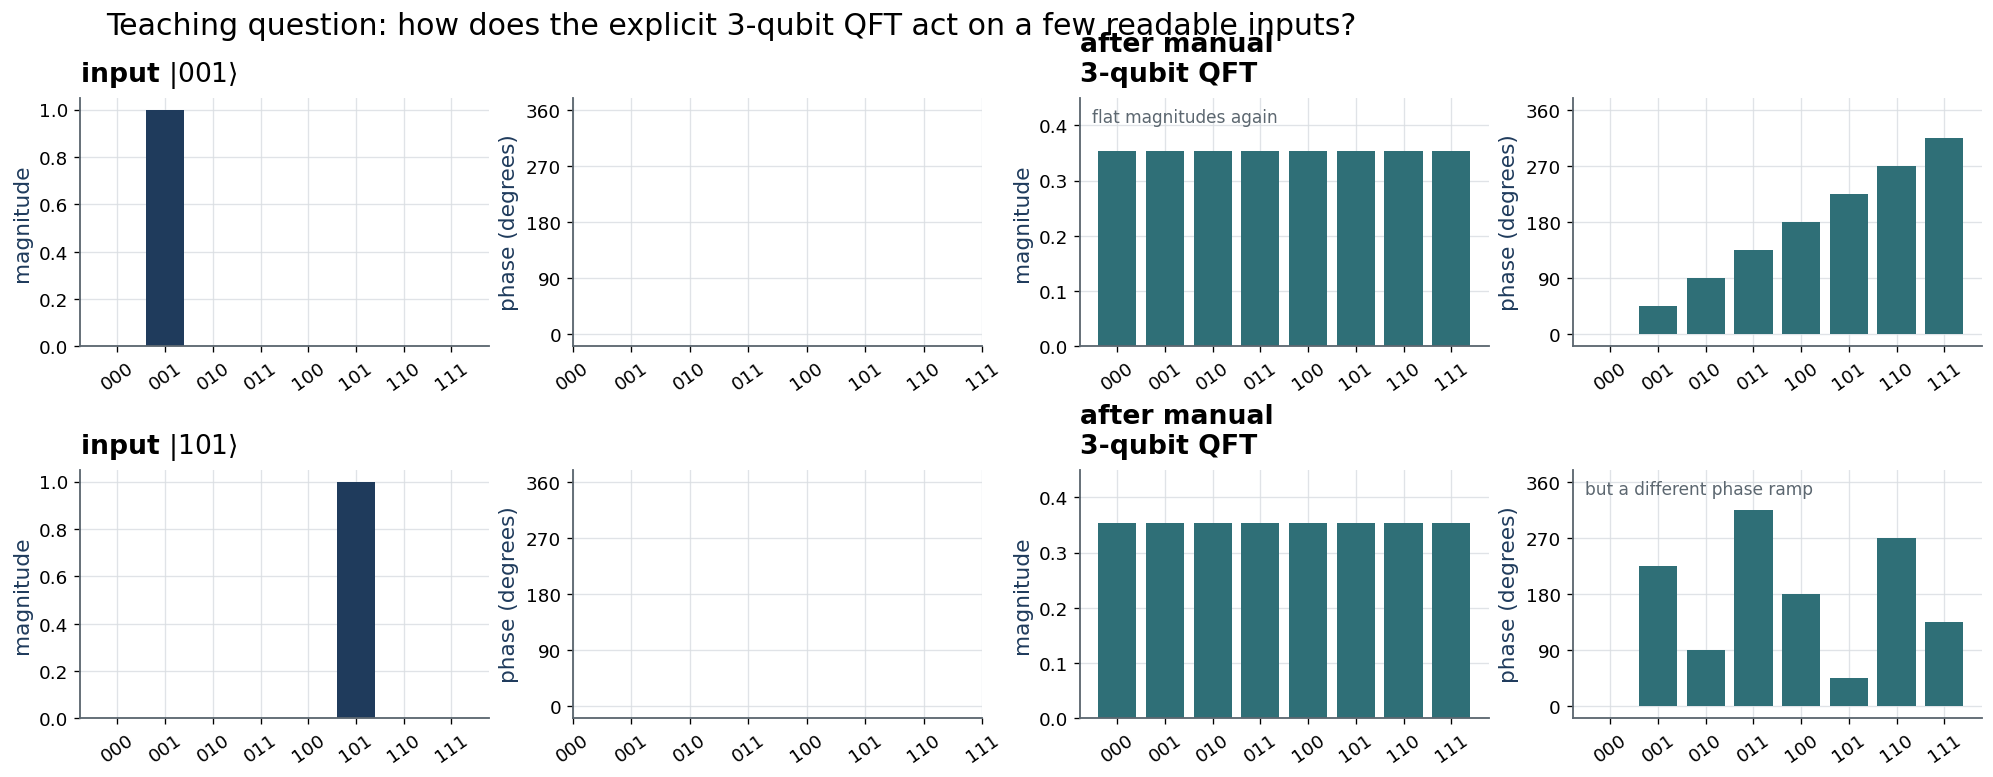

In [67]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


labels_3 = computational_labels(3)
sample_inputs_3 = ['001', '101']
fig, axes = plt.subplots(len(sample_inputs_3), 4, figsize=(16.5, 6.2), constrained_layout=True)

for row, label in enumerate(sample_inputs_3):
    # Keep the input visible so students can compare before and after directly.
    input_state = Statevector.from_label(label)
    output_state = input_state.evolve(manual_qft_3_explicit)

    # Input magnitudes and phases.
    axes[row, 0].bar(np.arange(len(labels_3)), np.abs(input_state.data), color=COLORS['navy'])
    axes[row, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 0].set_ylim(0, 1.05)
    axes[row, 0].set_ylabel('magnitude')
    axes[row, 0].set_title(f'input $|{label}\\rangle$', loc='left')
    axes[row, 1].bar(np.arange(len(labels_3)), phase_degrees(input_state.data), color=COLORS['navy'])
    axes[row, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 1].set_ylim(-20, 380)
    axes[row, 1].set_yticks([0, 90, 180, 270, 360])
    axes[row, 1].set_ylabel('phase (degrees)')

    # Output magnitudes and phases after the manual 3-qubit QFT.
    axes[row, 2].bar(np.arange(len(labels_3)), np.abs(output_state.data), color=COLORS['teal'])
    axes[row, 2].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 2].set_ylim(0, 0.45)
    axes[row, 2].set_ylabel('magnitude')
    axes[row, 2].set_title('after manual\n3-qubit QFT', loc='left')
    axes[row, 3].bar(np.arange(len(labels_3)), phase_degrees(output_state.data), color=COLORS['teal'])
    axes[row, 3].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
    axes[row, 3].set_ylim(-20, 380)
    axes[row, 3].set_yticks([0, 90, 180, 270, 360])
    axes[row, 3].set_ylabel('phase (degrees)')

axes[0, 2].text(0.03, 0.9, 'flat magnitudes again', transform=axes[0, 2].transAxes, fontsize=10.2, color=COLORS['gray'])
axes[1, 3].text(0.03, 0.9, 'but a different phase ramp', transform=axes[1, 3].transAxes, fontsize=10.2, color=COLORS['gray'])

fig.suptitle('Teaching question: how does the explicit 3-qubit QFT act on a few readable inputs?', x=0.05, ha='left', y=1.02)
plt.show()


> **Takeaway:** The 3-qubit manual circuit is longer, but not conceptually different. The extra controlled phase gates simply refine the phase pattern with more binary-fraction detail.

### Task 11.1 - Modify the 3-qubit QFT input and inspect the output

Use the manual 3-qubit circuit on at least one input state not shown above.

Your job:
- pick an input that you think will give an interesting phase pattern,
- apply `manual_qft_3_explicit`,
- inspect magnitudes and phases,
- identify where the final swap matters for the conventional output ordering.

If you want a stronger challenge, remove the final swap, run the circuit again, and track how the labels should be reinterpreted.


In [68]:
# Your code here
# Reuse manual_qft_3_explicit, or make a copy and remove the final swap for comparison.
# Suggested states: |010>, |111>, or a short superposition of your choice.
# Compare the output labels carefully if you remove swaps.
pass


## 12. Compare Manual and Library Implementations

**Concept question:** Does the hand-built circuit really match the library implementation, or are there hidden convention issues?

In this environment, the modern library object is `QFTGate`. The older `QFT` class is also available, but it is deprecated in Qiskit 2.3.0. For a clean comparison, we will therefore build library circuits using `QFTGate`.

The important comparison questions are:
- Do the decomposed circuits have the same structure?
- Do they implement the same unitary?
- Do they act the same way on concrete input states?

A mismatch caused only by swaps or qubit ordering is a **convention mismatch**, not an algorithmic disagreement. Here we keep swaps in both versions so the comparison is fair.

Manual 2-qubit QFT


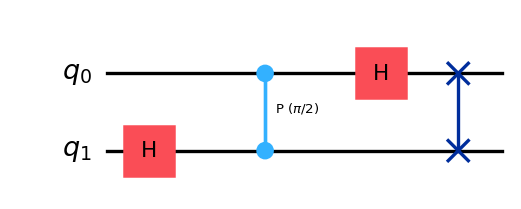

Library 2-qubit QFT (decomposed)


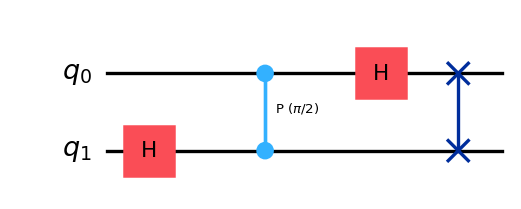

Manual 3-qubit QFT


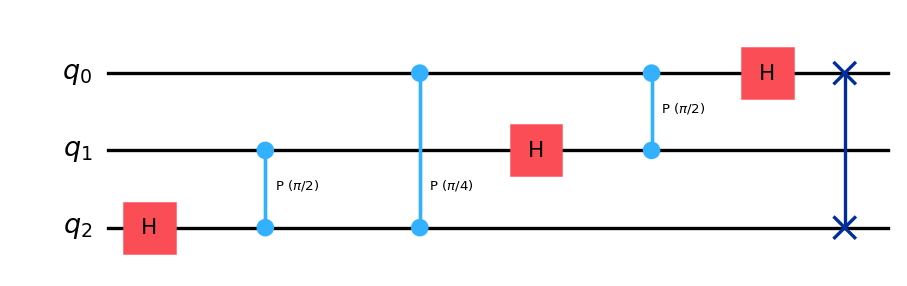

Library 3-qubit QFT (decomposed)


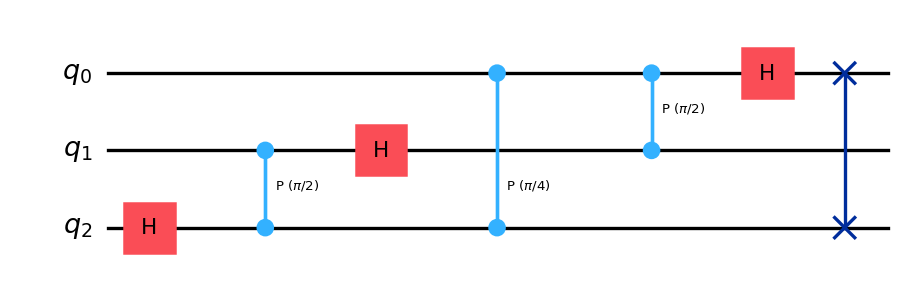

In [69]:
# Build the library circuits explicitly in the cell.
library_qft_2 = QuantumCircuit(2, name='lib_QFT_2')
library_qft_2.append(QFTGate(2), range(2))

library_qft_3 = QuantumCircuit(3, name='lib_QFT_3')
library_qft_3.append(QFTGate(3), range(3))

print('Manual 2-qubit QFT')
display(manual_qft_2_explicit.draw('mpl'))
print('Library 2-qubit QFT (decomposed)')
display(library_qft_2.decompose().draw('mpl'))

print('Manual 3-qubit QFT')
display(manual_qft_3_explicit.draw('mpl'))
print('Library 3-qubit QFT (decomposed)')
display(library_qft_3.decompose().draw('mpl'))


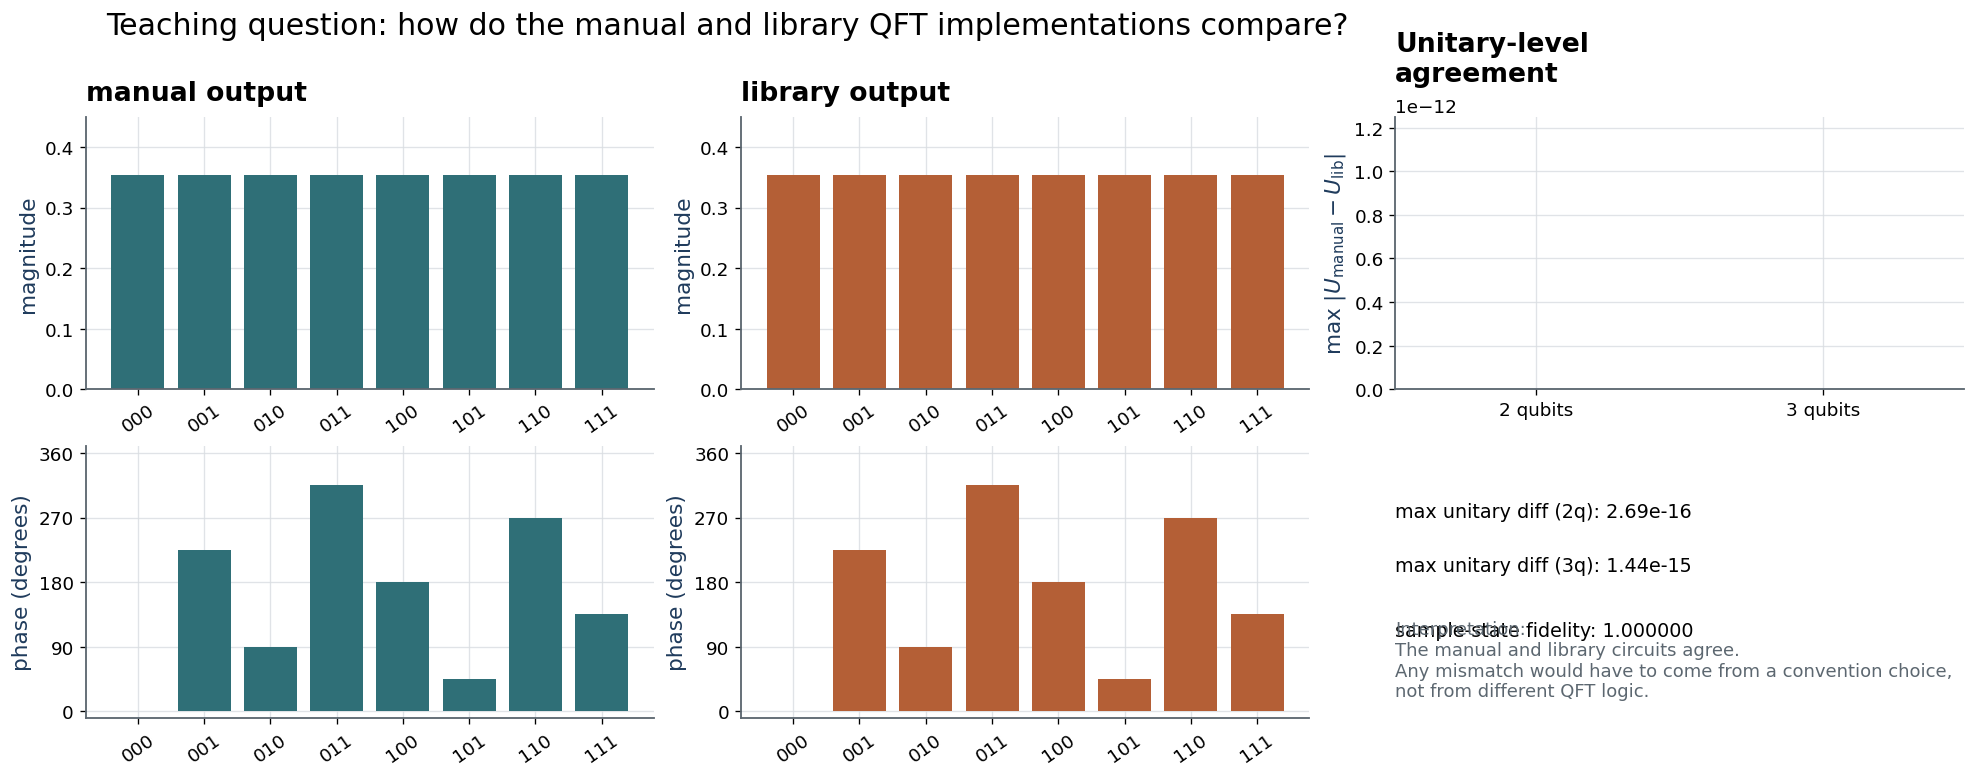

In [70]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


labels_3 = computational_labels(3)

# Compare the actual matrices implemented by the manual and library circuits.
manual_unitary_diff_2 = np.max(np.abs(Operator(manual_qft_2_explicit).data - Operator(library_qft_2).data))
manual_unitary_diff_3 = np.max(np.abs(Operator(manual_qft_3_explicit).data - Operator(library_qft_3).data))

# Also compare the action on one concrete state, not just the full unitary.
sample_input = Statevector.from_label('101')
manual_output = sample_input.evolve(manual_qft_3_explicit)
library_output = sample_input.evolve(library_qft_3)
sample_fidelity = np.abs(np.vdot(manual_output.data, library_output.data)) ** 2

fig, axes = plt.subplots(2, 3, figsize=(16.5, 6.2), constrained_layout=True)

# Manual output: magnitudes and phases.
axes[0, 0].bar(np.arange(len(labels_3)), np.abs(manual_output.data), color=COLORS['teal'])
axes[0, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 0].set_ylim(0, 0.45)
axes[0, 0].set_ylabel('magnitude')
axes[0, 0].set_title('manual output', loc='left')
axes[1, 0].bar(np.arange(len(labels_3)), phase_degrees(manual_output.data), color=COLORS['teal'])
axes[1, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 0].set_ylim(-10, 370)
axes[1, 0].set_yticks([0, 90, 180, 270, 360])
axes[1, 0].set_ylabel('phase (degrees)')

# Library output: same plotting style for a fair visual comparison.
axes[0, 1].bar(np.arange(len(labels_3)), np.abs(library_output.data), color=COLORS['rust'])
axes[0, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 1].set_ylim(0, 0.45)
axes[0, 1].set_ylabel('magnitude')
axes[0, 1].set_title('library output', loc='left')
axes[1, 1].bar(np.arange(len(labels_3)), phase_degrees(library_output.data), color=COLORS['rust'])
axes[1, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 1].set_ylim(-10, 370)
axes[1, 1].set_yticks([0, 90, 180, 270, 360])
axes[1, 1].set_ylabel('phase (degrees)')

# Unitary-level comparison: if these bars are near zero, the circuits match numerically.
axes[0, 2].bar(['2 qubits', '3 qubits'], [manual_unitary_diff_2, manual_unitary_diff_3], color=[COLORS['navy'], COLORS['gold']])
axes[0, 2].set_ylabel(r'max $|U_{\mathrm{manual}} - U_{\mathrm{lib}}|$')
axes[0, 2].set_title('Unitary-level\nagreement', loc='left')
axes[0, 2].set_ylim(0, max(manual_unitary_diff_2, manual_unitary_diff_3, 1e-12) * 1.25 + 1e-15)

# Summary text: spell out the numerical agreement.
axes[1, 2].axis('off')
axes[1, 2].text(0.0, 0.74, f'max unitary diff (2q): {manual_unitary_diff_2:.2e}', fontsize=11.5)
axes[1, 2].text(0.0, 0.54, f'max unitary diff (3q): {manual_unitary_diff_3:.2e}', fontsize=11.5)
axes[1, 2].text(0.0, 0.30, f'sample-state fidelity: {sample_fidelity:.6f}', fontsize=11.5)
axes[1, 2].text(0.0, 0.08, 'Interpretation:\nThe manual and library circuits agree.\nAny mismatch would have to come from a convention choice,\nnot from different QFT logic.', fontsize=10.8, color=COLORS['gray'])

fig.suptitle('Teaching question: how do the manual and library QFT implementations compare?', x=0.05, ha='left', y=1.02)
plt.show()


The comparison is useful in two ways:
- structurally, the decomposed library circuit matches the hand-built gate pattern,
- operationally, the unitary and state-action checks show that the two implementations agree.

> **Takeaway:** Once swaps and ordering conventions are matched, the manual and library QFT circuits represent the same transformation.

### Task 12.1 - Check manual versus library QFT on your own example

Run your own comparison between the manual and library QFT on a state of your choice.

Your job:
- choose one 2-qubit or 3-qubit input state,
- evolve it with the manual circuit and the library circuit,
- compare the outputs numerically,
- decide whether any difference is algorithmic or just a convention issue.

Record your conclusion in one short sentence.


In [71]:
# Your code here
# Suggested variables: comparison_input, manual_state, library_state.
# Compute a fidelity or max amplitude difference.
# If you suspect a mismatch, check swaps or qubit-order conventions before concluding.
pass


## 13. Apply QFT Then Inverse QFT and Verify Recovery

**Concept question:** What should happen if we apply QFT and then inverse QFT to a state?

If the constructions are correct, the composition should recover the original state. This does not only test one basis input. It should work for any state in the register, including superpositions and states with nontrivial relative phases.

That recovery test is important because it checks the whole phase-encoding and phase-decoding story in one step.

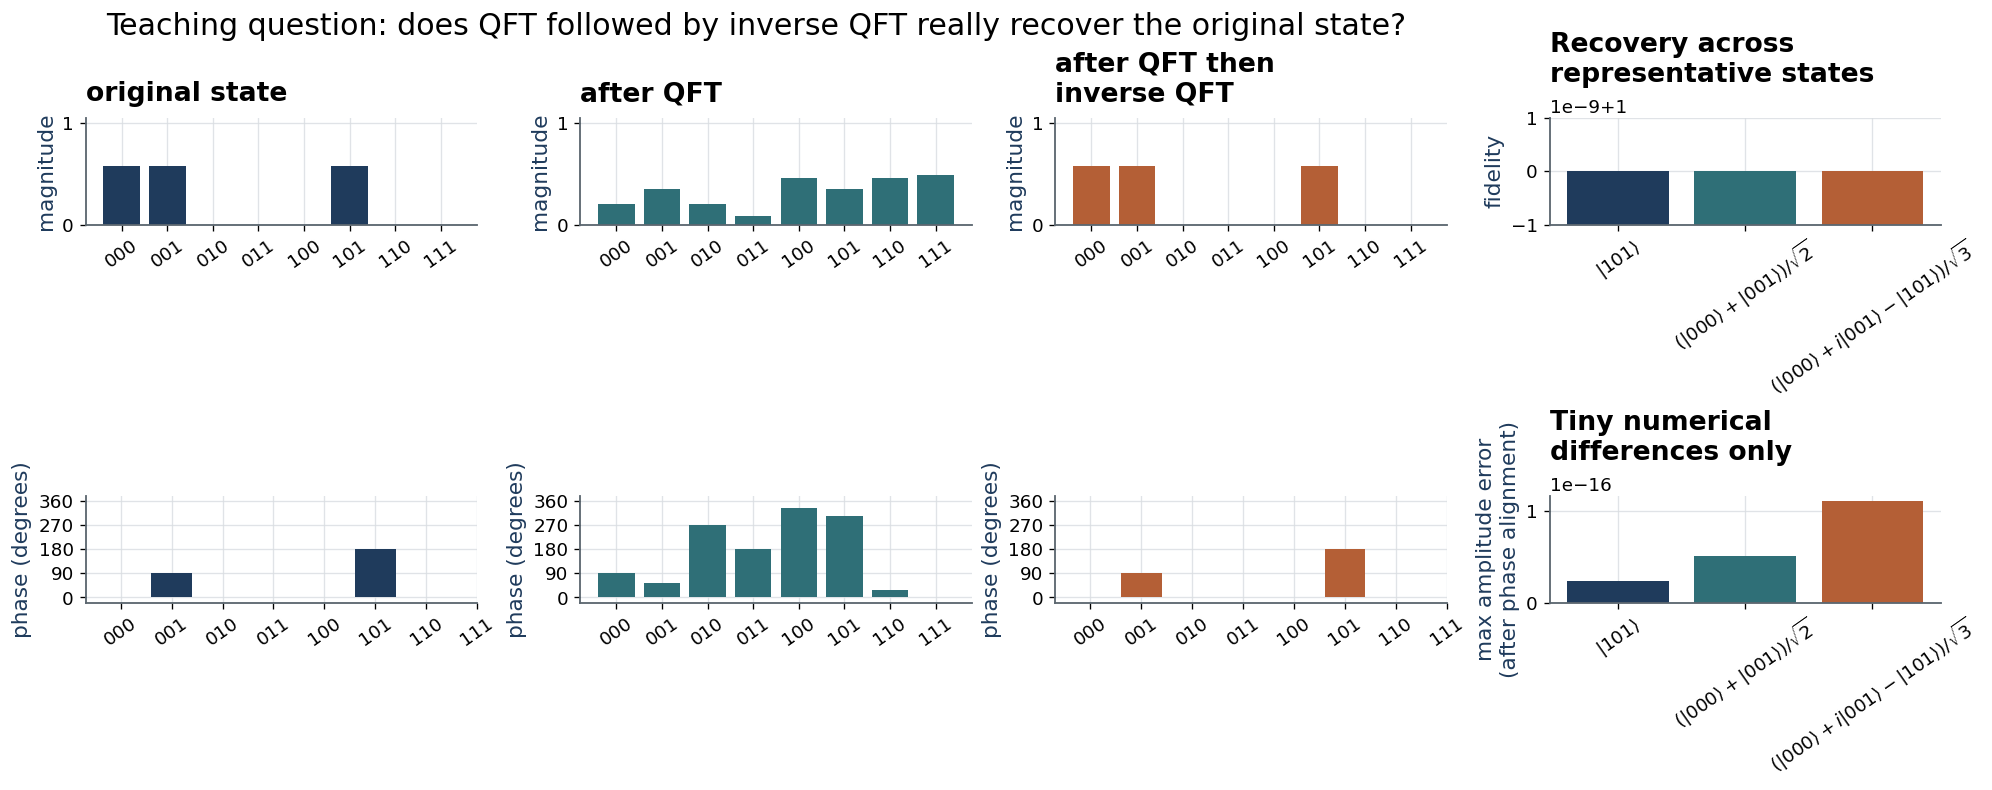

In [72]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def basis_ket(num_qubits, index):
    vector = np.zeros(2**num_qubits, dtype=complex)
    vector[index] = 1.0
    return vector


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


# Build the forward and inverse circuits explicitly in the cell.
explicit_qft_3 = QuantumCircuit(3)
explicit_qft_3.h(2)
explicit_qft_3.cp(np.pi / 2, 1, 2)
explicit_qft_3.cp(np.pi / 4, 0, 2)
explicit_qft_3.h(1)
explicit_qft_3.cp(np.pi / 2, 0, 1)
explicit_qft_3.h(0)
explicit_qft_3.swap(0, 2)

explicit_iqft_3 = explicit_qft_3.inverse()
qft_then_iqft = explicit_iqft_3.compose(explicit_qft_3)

# Test basis, superposition, and phase-rich inputs.
test_states = {
    r'$|101\rangle$': Statevector.from_label('101'),
    r'$(|000\rangle + |001\rangle)/\sqrt{2}$': Statevector((basis_ket(3, 0) + basis_ket(3, 1)) / np.sqrt(2)),
    r'$(|000\rangle + i|001\rangle - |101\rangle)/\sqrt{3}$': Statevector((basis_ket(3, 0) + 1j * basis_ket(3, 1) - basis_ket(3, 5)) / np.sqrt(3)),
}

fidelities = []
max_errors = []

# Align global phase before comparing amplitudes entry by entry.
def align_global_phase(reference, trial):
    pivot = np.argmax(np.abs(reference))
    phase = 1.0 if np.abs(reference[pivot]) < 1e-12 else trial[pivot] / reference[pivot]
    return trial / phase

for label, state in test_states.items():
    recovered = state.evolve(qft_then_iqft)
    fidelity = np.abs(np.vdot(state.data, recovered.data)) ** 2
    fidelities.append(fidelity)

    aligned_recovered = align_global_phase(state.data, recovered.data)
    max_errors.append(np.max(np.abs(aligned_recovered - state.data)))

# Use the most phase-rich test state as the representative visual example.
representative_label = r'$(|000\rangle + i|001\rangle - |101\rangle)/\sqrt{3}$'
representative_state = test_states[representative_label]
after_qft = representative_state.evolve(explicit_qft_3)
after_recovery = representative_state.evolve(qft_then_iqft)

fig, axes = plt.subplots(2, 4, figsize=(16.5, 6.3), constrained_layout=True)

# Original state.
axes[0, 0].bar(np.arange(len(labels_3)), np.abs(representative_state.data), color=COLORS['navy'])
axes[0, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].set_ylabel('magnitude')
axes[0, 0].set_title('original state', loc='left')
axes[1, 0].bar(np.arange(len(labels_3)), phase_degrees(representative_state.data), color=COLORS['navy'])
axes[1, 0].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 0].set_ylim(-20, 380)
axes[1, 0].set_yticks([0, 90, 180, 270, 360])
axes[1, 0].set_ylabel('phase (degrees)')

# After QFT.
axes[0, 1].bar(np.arange(len(labels_3)), np.abs(after_qft.data), color=COLORS['teal'])
axes[0, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].set_ylabel('magnitude')
axes[0, 1].set_title('after QFT', loc='left')
axes[1, 1].bar(np.arange(len(labels_3)), phase_degrees(after_qft.data), color=COLORS['teal'])
axes[1, 1].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 1].set_ylim(-20, 380)
axes[1, 1].set_yticks([0, 90, 180, 270, 360])
axes[1, 1].set_ylabel('phase (degrees)')

# After inverse QFT.
axes[0, 2].bar(np.arange(len(labels_3)), np.abs(after_recovery.data), color=COLORS['rust'])
axes[0, 2].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[0, 2].set_ylim(0, 1.05)
axes[0, 2].set_ylabel('magnitude')
axes[0, 2].set_title('after QFT then\ninverse QFT', loc='left')
axes[1, 2].bar(np.arange(len(labels_3)), phase_degrees(after_recovery.data), color=COLORS['rust'])
axes[1, 2].set_xticks(np.arange(len(labels_3)), labels_3, rotation=35)
axes[1, 2].set_ylim(-20, 380)
axes[1, 2].set_yticks([0, 90, 180, 270, 360])
axes[1, 2].set_ylabel('phase (degrees)')

# Recovery quality across all test states.
axes[0, 3].bar(list(test_states.keys()), fidelities, color=[COLORS['navy'], COLORS['teal'], COLORS['rust']])
axes[0, 3].set_ylim(0.999999999, 1.000000001)
axes[0, 3].tick_params(axis='x', rotation=35)
axes[0, 3].set_ylabel('fidelity')
axes[0, 3].set_title('Recovery across\nrepresentative states', loc='left')

axes[1, 3].bar(list(test_states.keys()), max_errors, color=[COLORS['navy'], COLORS['teal'], COLORS['rust']])
axes[1, 3].tick_params(axis='x', rotation=35)
axes[1, 3].set_ylabel('max amplitude error\n(after phase alignment)')
axes[1, 3].set_title('Tiny numerical\ndifferences only', loc='left')

fig.suptitle('Teaching question: does QFT followed by inverse QFT really recover the original state?', x=0.05, ha='left', y=1.02)
plt.show()


The recovery test confirms the expected behavior:
- the representative state returns to its original magnitude-and-phase description,
- fidelities are essentially $1$ for all tested states,
- any tiny mismatch comes from floating-point arithmetic rather than from a failure of the algorithm.

### Checkpoint Prompt
What does this test confirm?
- It confirms that our QFT and inverse-QFT constructions are operational inverses on the tested states.

What does it **not** yet tell us?
- It does not yet explain how an algorithm uses inverse QFT to decode useful phase information from a larger computation. That comes next, in phase estimation.

> **Takeaway:** The recovery test is the cleanest hands-on check that QFT is a genuine reversible transformation whose inverse can undo the phase encoding it creates.

### Task 13.1 - Test QFT followed by inverse QFT on a new state

Design one additional 3-qubit test state with nontrivial relative phases.

Your job:
1. build the state,
2. apply QFT and then inverse QFT,
3. compute a fidelity with the original state,
4. align global phase if you compare amplitudes entry by entry,
5. explain what this confirms and what it still does **not** prove about a larger algorithm.


In [73]:
# Your code here
# Reuse explicit_qft_3 and explicit_iqft_3 if they are already defined above.
# Suggested idea: include at least one imaginary coefficient and at least one minus sign.
# Compute fidelity and, if useful, a max amplitude error after global-phase alignment.
pass


## 14. QFT and Phase Estimation

**Concept question:** Why does inverse QFT appear so often in phase estimation circuits?

Phase estimation starts from a unitary eigenvalue relation
$$
U|u\rangle = e^{2\pi i \phi}|u\rangle,
\qquad 0 \leq \phi < 1.
$$

The target register is prepared in the eigenstate $|u\rangle$. A separate control register is placed into superposition. Then controlled powers of $U$ are applied:
- one control qubit triggers $U$,
- the next triggers $U^2$,
- the next triggers $U^4$,
- and so on.

Because the target is an eigenstate, these controlled powers do not scramble it into something complicated. Instead, they write a **structured phase pattern** onto the control register. That is the key point.

At that stage, the useful information is present, but it is still stored as a phase-coded superposition. The inverse QFT is then used as the **decoding step**: it reorganizes that phase pattern into a computational-basis outcome that can be read out by measurement.

So phase estimation is best understood as:

> **phase encoding by controlled powers of a unitary, followed by inverse-QFT decoding.**

That is where the QFT gets real algorithmic significance. It is not just an interesting transform in isolation; it is what turns an invisible phase pattern into a readable register value.

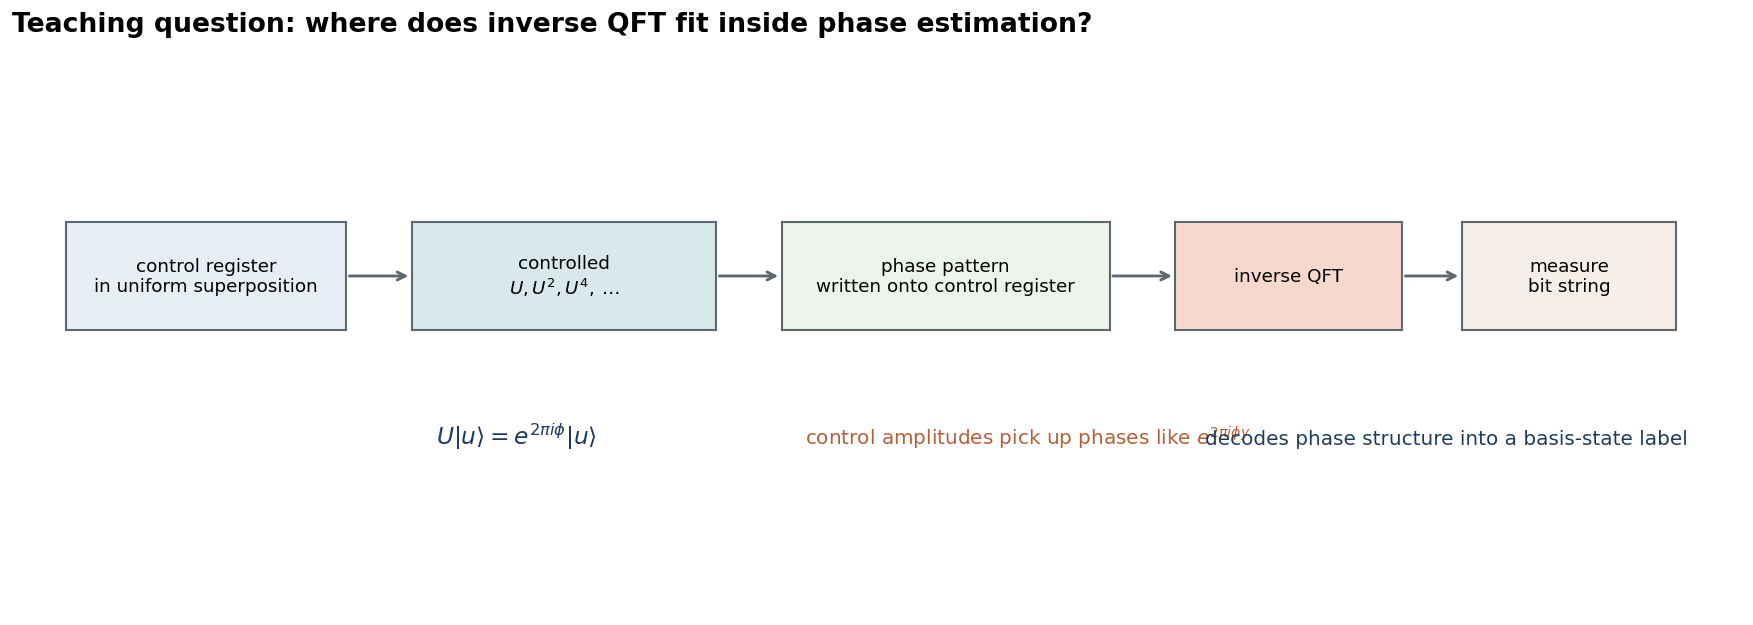

In [74]:
fig, ax = plt.subplots(figsize=(14.5, 5.1), constrained_layout=True)
ax.set_xlim(0, 14.5)
ax.set_ylim(0, 5.2)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

boxes = [
    (0.45, 2.6, 2.35, 1.0, 'control register\nin uniform superposition', '#e7eef6'),
    (3.35, 2.6, 2.55, 1.0, 'controlled\n$U, U^2, U^4, \dots$', '#d9e8ea'),
    (6.45, 2.6, 2.75, 1.0, 'phase pattern\nwritten onto control register', '#eef4eb'),
    (9.75, 2.6, 1.9, 1.0, 'inverse QFT', '#f6d9cc'),
    (12.15, 2.6, 1.8, 1.0, 'measure\nbit string', '#f6efe9'),
]

for x0, y0, w, h, text, color in boxes:
    rect = Rectangle((x0, y0), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.25)
    ax.add_patch(rect)
    ax.text(x0 + w / 2, y0 + h / 2, text, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.8, 3.35), (5.9, 6.45), (9.2, 9.75), (11.65, 12.15)]:
    ax.annotate('', xy=(x1, 3.1), xytext=(x0, 3.1), arrowprops={'arrowstyle': '->', 'linewidth': 1.7, 'color': COLORS['gray']})

ax.text(3.55, 1.55, r'$U|u\rangle = e^{2\pi i\phi}|u\rangle$', fontsize=14, color=COLORS['navy'])
ax.text(6.65, 1.55, r'control amplitudes pick up phases like $e^{2\pi i\phi y}$', fontsize=12, color=COLORS['rust'])
ax.text(10.0, 1.55, 'decodes phase structure into a basis-state label', fontsize=12, color=COLORS['navy'])
ax.set_title('Teaching question: where does inverse QFT fit inside phase estimation?', loc='left')
plt.show()


> **Takeaway:** In phase estimation, inverse QFT is the stage that turns a phase-encoded control register into a measurement-ready computational-basis outcome.

### Task 14.1 - Inspect a control-register phase pattern directly

Work with the phase-estimation formula in a tiny exact case.

Choose a phase such as $\phi = 1/8$, $1/4$, or $3/8$. For a 2-qubit control register, compute the phase factors
$$
e^{2\pi i \phi y}, \qquad y = 0,1,2,3.
$$

Your job:
- list the four complex phase factors,
- convert them to phase angles,
- explain which part of the pattern inverse QFT is supposed to decode.


In [75]:
# Your code here
# Pick phi and compute np.exp(2j * np.pi * phi * y) for y = 0, 1, 2, 3.
# Print both the complex numbers and their phases in degrees.
# Then add a short markdown interpretation below.
pass


## 15. Toy Phase-Estimation-Style Example

**Concept question:** Can we see the phase-estimation logic in a tiny circuit where the answer is easy to predict in advance?

Yes. We will use:
- a **2-qubit control register**, so the decoded answer is only two bits long,
- a **1-qubit target register** prepared in $|1\rangle$,
- the unitary $U = P(\pi/2)$ acting on the target, so
$$
U|1\rangle = e^{i\pi/2}|1\rangle = e^{2\pi i (1/4)} |1\rangle.
$$

So the exact eigenphase is
$$
\phi = \frac{1}{4} = 0.01_2.
$$

This is intentionally idealized:
- the target is already an eigenstate,
- the phase has an exact two-bit binary expansion,
- and the circuit is chosen for transparency, not realism.

That is a feature, not a bug. It isolates the decoding logic we want to see.

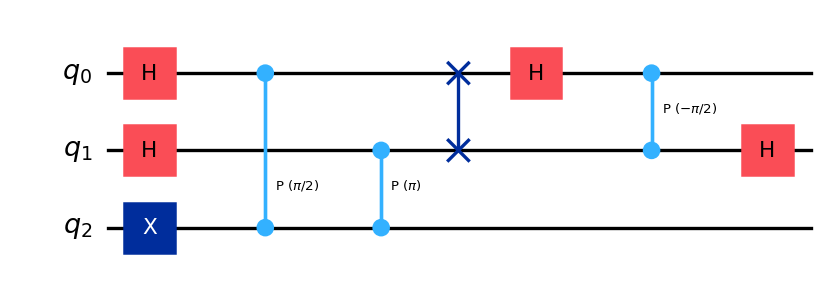

In [76]:
toy_pe_circuit = QuantumCircuit(3, name='toy_phase_estimation')

# Step 1: put the 2-qubit control register into a uniform superposition.
toy_pe_circuit.h(0)
toy_pe_circuit.h(1)

# Step 2: prepare the target qubit in |1>, an eigenstate of P(pi/2).
toy_pe_circuit.x(2)

# Step 3: encode the phase using controlled powers of U.
# q0 controls U = P(pi/2), so it adds phase e^{2 pi i (1/4)} when the control is 1.
toy_pe_circuit.cp(np.pi / 2, 0, 2)
# q1 controls U^2 = P(pi), which contributes the next binary digit of the phase.
toy_pe_circuit.cp(np.pi, 1, 2)

# Step 4: decode the control-register phase pattern with an explicit inverse QFT.
inverse_qft_2 = QuantumCircuit(2, name='inverse_QFT_2')
inverse_qft_2.swap(0, 1)
inverse_qft_2.h(0)
inverse_qft_2.cp(-np.pi / 2, 0, 1)
inverse_qft_2.h(1)
toy_pe_circuit.compose(inverse_qft_2, qubits=[0, 1], inplace=True)

display(toy_pe_circuit.draw('mpl'))


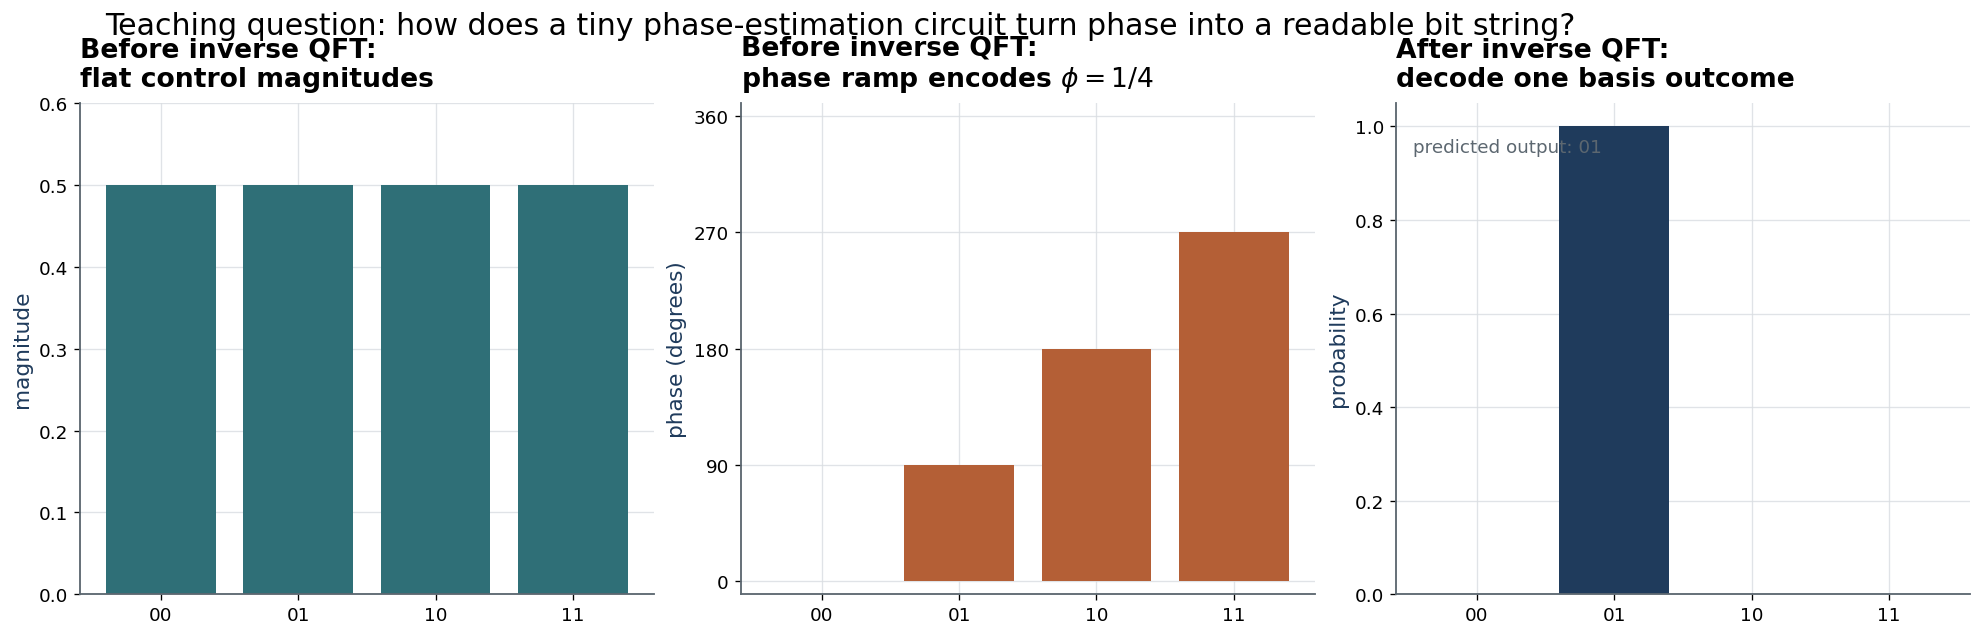

Predicted phase: phi = 1/4 = 0.01_2
Decoded control-register probabilities: {'00': 2.4033994692808056e-33, '01': 0.9999999999999993, '10': 2.4033994692808063e-33, '11': 3.872928019572694e-37}


In [77]:
def computational_labels(num_qubits):
    return [format(index, f'0{num_qubits}b') for index in range(2**num_qubits)]


def phase_degrees(state):
    data = np.asarray(state, dtype=complex)
    phases = (np.degrees(np.angle(data)) + 360) % 360
    phases[np.abs(data) < 1e-10] = np.nan
    return phases


# Build the "phase-encoding only" part separately so we can inspect the control register before inverse QFT.
phase_encode_only = QuantumCircuit(3)
phase_encode_only.h(0)
phase_encode_only.h(1)
phase_encode_only.x(2)
phase_encode_only.cp(np.pi / 2, 0, 2)
phase_encode_only.cp(np.pi, 1, 2)

encoded_state = Statevector.from_instruction(phase_encode_only)
decoded_state = Statevector.from_instruction(toy_pe_circuit)

# Because the target remains in |1>, the last four amplitudes correspond to the control register.
encoded_control_state = Statevector(encoded_state.data[4:8])
control_labels_2 = computational_labels(2)

# Read out only the control-register probabilities after the inverse-QFT decoding step.
decoded_control_probs = decoded_state.probabilities([0, 1])
expected_label = '01'

fig, axes = plt.subplots(1, 3, figsize=(16.4, 5.0), constrained_layout=True)

# Before inverse QFT: magnitudes are all equal.
axes[0].bar(np.arange(4), np.abs(encoded_control_state.data), color=COLORS['teal'])
axes[0].set_xticks(np.arange(4), control_labels_2)
axes[0].set_ylim(0, 0.6)
axes[0].set_ylabel('magnitude')
axes[0].set_title('Before inverse QFT:\nflat control magnitudes', loc='left')

# Before inverse QFT: the useful information is in the phase ramp.
axes[1].bar(np.arange(4), phase_degrees(encoded_control_state.data), color=COLORS['rust'])
axes[1].set_xticks(np.arange(4), control_labels_2)
axes[1].set_ylim(-10, 370)
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].set_ylabel('phase (degrees)')
axes[1].set_title('Before inverse QFT:\nphase ramp encodes $\phi=1/4$', loc='left')

# After inverse QFT: the control register becomes a readable computational-basis label.
axes[2].bar(np.arange(4), decoded_control_probs, color=COLORS['navy'])
axes[2].set_xticks(np.arange(4), control_labels_2)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel('probability')
axes[2].set_title('After inverse QFT:\ndecode one basis outcome', loc='left')
axes[2].text(0.03, 0.9, f'predicted output: {expected_label}', transform=axes[2].transAxes, fontsize=11, color=COLORS['gray'])

fig.suptitle('Teaching question: how does a tiny phase-estimation circuit turn phase into a readable bit string?', x=0.05, ha='left', y=1.03)
plt.show()

print('Predicted phase: phi = 1/4 = 0.01_2')
print('Decoded control-register probabilities:', {label: float(prob) for label, prob in zip(control_labels_2, decoded_control_probs)})


The toy example makes the mechanism explicit:
- before inverse QFT, the control register has equal magnitudes but a structured phase pattern,
- after inverse QFT, the probability mass concentrates on the computational-basis label `01`,
- and that output matches the exact two-bit binary phase $0.01_2$.

> **Takeaway:** This tiny example is idealized, but it shows the real logic of phase estimation: controlled powers encode phase, and inverse QFT decodes it.

### Task 15.1 - Change the toy phase-estimation example

Modify the toy example so the eigenphase is still exactly representable with two control qubits, but different from $\phi = 1/4$.

A good choice is
$$
\phi = \frac{3}{4} = 0.11_2.
$$

Your job:
- update the controlled phase gates so the target eigenstate acquires the new phase,
- predict the output bit string before you run the circuit,
- verify the decoded control-register probabilities,
- explain what was idealized in this toy construction.


In [78]:
# Your code here
# Build a modified toy phase-estimation circuit for a new exact binary phase.
# Suggested target: phi = 3/4, which should decode to 11 on a 2-qubit control register.
# Reuse the structure of toy_pe_circuit, but change the controlled-phase angles consistently.
pass


## 16. Brief Connection to Shor’s Algorithm

**Concept question:** Why does all of this matter beyond one toy circuit?

Shor's algorithm is not "just QFT." It is a larger period-finding algorithm with both quantum and classical parts. But the QFT matters because period-finding creates a phase-structured signal, and phase-estimation-style ideas are what make that signal readable.

At a high level:
- modular arithmetic creates a hidden periodic structure,
- the quantum part turns that periodic structure into phase information across a register,
- QFT or inverse-QFT machinery helps convert that phase structure into a basis-state pattern,
- classical post-processing then turns the extracted periodic information into candidate factors.

So the right message is not that QFT alone solves factoring. The right message is that QFT is part of the machinery that helps extract hidden periodic structure efficiently.

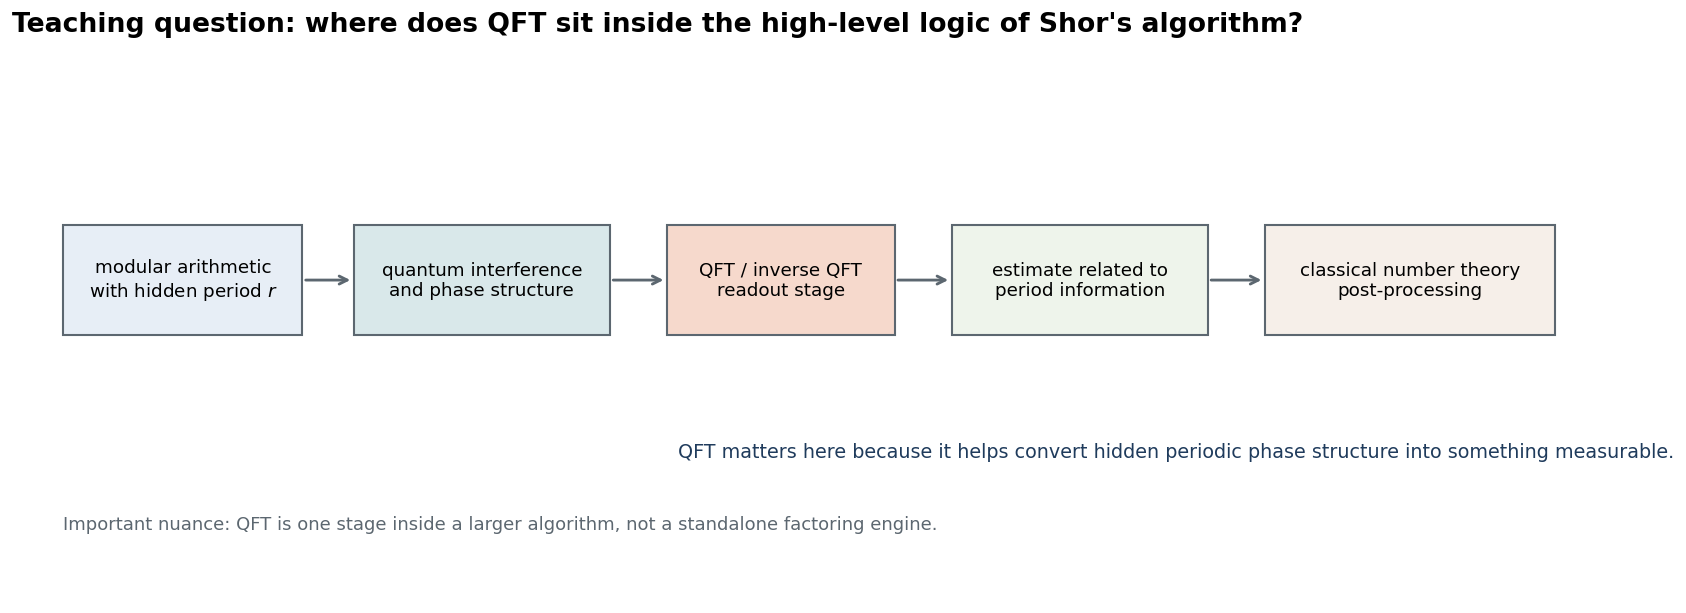

In [79]:
fig, ax = plt.subplots(figsize=(14.5, 5.0), constrained_layout=True)
ax.set_xlim(0, 14.5)
ax.set_ylim(0, 5.0)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

boxes = [
    (0.45, 2.4, 2.1, 1.0, 'modular arithmetic\nwith hidden period $r$', '#e7eef6'),
    (3.0, 2.4, 2.25, 1.0, 'quantum interference\nand phase structure', '#d9e8ea'),
    (5.75, 2.4, 2.0, 1.0, 'QFT / inverse QFT\nreadout stage', '#f6d9cc'),
    (8.25, 2.4, 2.25, 1.0, 'estimate related to\nperiod information', '#eef4eb'),
    (11.0, 2.4, 2.55, 1.0, 'classical number theory\npost-processing', '#f6efe9'),
]

for x0, y0, w, h, text, color in boxes:
    rect = Rectangle((x0, y0), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.25)
    ax.add_patch(rect)
    ax.text(x0 + w / 2, y0 + h / 2, text, ha='center', va='center', fontsize=11)

for x0, x1 in [(2.55, 3.0), (5.25, 5.75), (7.75, 8.25), (10.5, 11.0)]:
    ax.annotate('', xy=(x1, 2.9), xytext=(x0, 2.9), arrowprops={'arrowstyle': '->', 'linewidth': 1.7, 'color': COLORS['gray']})

ax.text(5.85, 1.3, 'QFT matters here because it helps convert hidden periodic phase structure into something measurable.', fontsize=11.5, color=COLORS['navy'])
ax.text(0.45, 0.65, 'Important nuance: QFT is one stage inside a larger algorithm, not a standalone factoring engine.', fontsize=10.8, color=COLORS['gray'])
ax.set_title('Teaching question: where does QFT sit inside the high-level logic of Shor\'s algorithm?', loc='left')
plt.show()


> **Takeaway:** The Shor connection is meaningful but limited: QFT helps extract hidden periodic structure, but the full factoring algorithm also depends on modular arithmetic structure and classical post-processing.

## 17. Summary and Further Exercises

This notebook followed one continuous arc:
- classical Fourier intuition motivated representation changes,
- phase became a real computational resource rather than bookkeeping,
- QFT appeared as a phase-structured basis change,
- the circuit anatomy showed how that change is built from simple gates,
- inverse QFT gave the decoding step,
- phase estimation showed why that decoding matters algorithmically,
- and Shor's algorithm provided the high-level application context.

The main message to keep is this:

> **QFT is useful because it reorganizes phase structure into a form that later computation or measurement can use.**

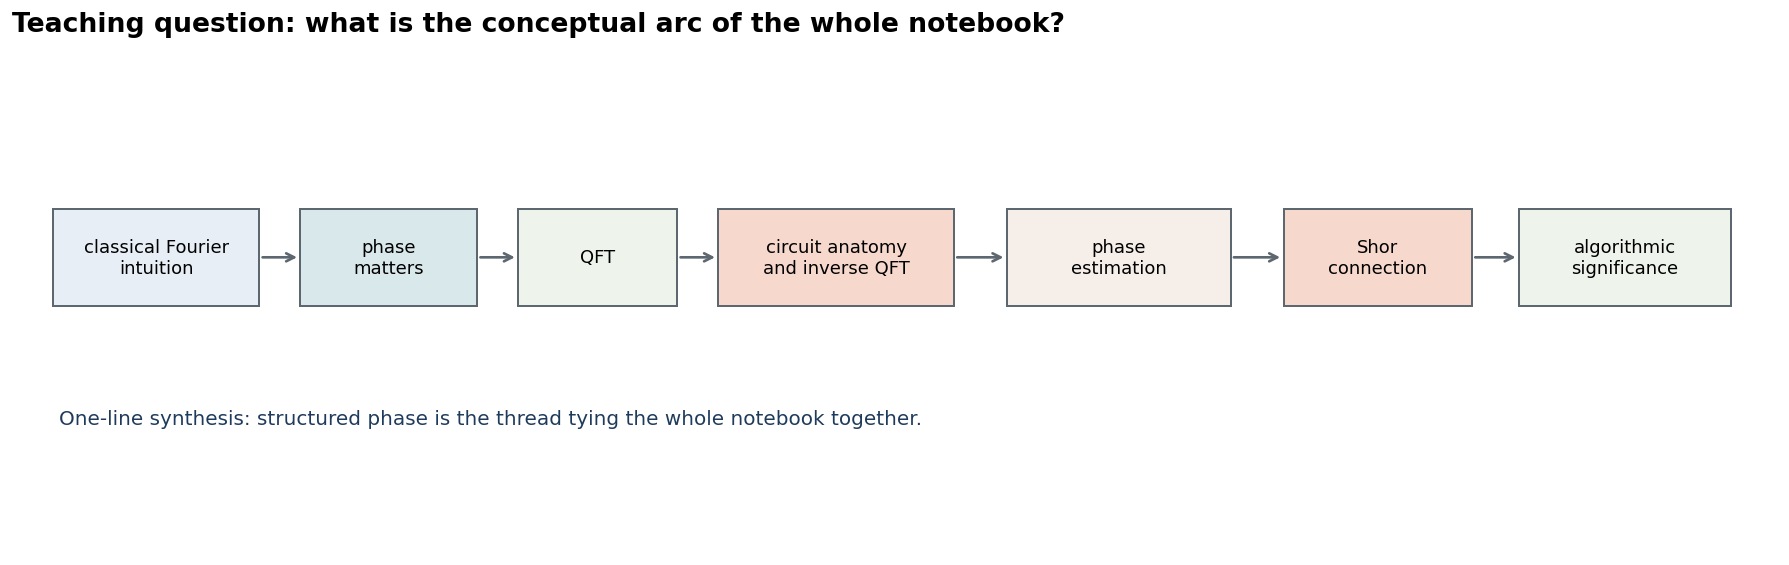

In [80]:
fig, ax = plt.subplots(figsize=(14.8, 4.6), constrained_layout=True)
ax.set_xlim(0, 15)
ax.set_ylim(0, 4.7)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

summary_boxes = [
    (0.35, 2.3, 1.75, 0.9, 'classical Fourier\nintuition', '#e7eef6'),
    (2.45, 2.3, 1.5, 0.9, 'phase\nmatters', '#d9e8ea'),
    (4.3, 2.3, 1.35, 0.9, 'QFT', '#eef4eb'),
    (6.0, 2.3, 2.0, 0.9, 'circuit anatomy\nand inverse QFT', '#f6d9cc'),
    (8.45, 2.3, 1.9, 0.9, 'phase\nestimation', '#f6efe9'),
    (10.8, 2.3, 1.6, 0.9, 'Shor\nconnection', '#f6d9cc'),
    (12.8, 2.3, 1.8, 0.9, 'algorithmic\nsignificance', '#eef4eb'),
]

for x0, y0, w, h, text, color in summary_boxes:
    rect = Rectangle((x0, y0), w, h, facecolor=color, edgecolor=COLORS['gray'], linewidth=1.2)
    ax.add_patch(rect)
    ax.text(x0 + w / 2, y0 + h / 2, text, ha='center', va='center', fontsize=10.8)

for x0, x1 in [(2.1, 2.45), (3.95, 4.3), (5.65, 6.0), (8.0, 8.45), (10.35, 10.8), (12.4, 12.8)]:
    ax.annotate('', xy=(x1, 2.75), xytext=(x0, 2.75), arrowprops={'arrowstyle': '->', 'linewidth': 1.6, 'color': COLORS['gray']})

ax.text(0.4, 1.2, 'One-line synthesis: structured phase is the thread tying the whole notebook together.', fontsize=12, color=COLORS['navy'])
ax.set_title('Teaching question: what is the conceptual arc of the whole notebook?', loc='left')
plt.show()


**Further exercises**
- Remove the final swaps from a small QFT circuit and track the qubit-order convention manually.
- Build an approximate QFT by dropping the smallest-angle controlled phase gates and compare the output with the exact version.
- Test QFT on more structured inputs, such as periodic superpositions or states with hand-designed phase ramps.
- Modify the toy phase-estimation example to use a different exact binary phase, such as $\phi = 1/8$ or $\phi = 3/8$.
- Compare different state visualizations and decide which one makes QFT phase structure easiest to interpret.

> **Final takeaway:** QFT matters because it gives quantum algorithms a controlled way to move between basis labels and structured phase information. That is why it keeps appearing in the core toolkit of quantum algorithm design.